In [1]:
from jax import config
config.update("jax_enable_x64", True)

import jax
from jax import lax
from jax import numpy as jnp
from jax.scipy.fft import dctn, idctn
import numpy as np
from functools import partial

from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast
from uot.utils.central_gradient_nd import _central_gradient_nd

from collections.abc import Sequence
from typing import Optional
from functools import reduce

from uot.data.measure import GridMeasure

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from matplotlib import pyplot as plt

In [2]:
plt.rcParams['figure.dpi'] = 120  # Set the display DPI for inline plots
plt.rcParams['savefig.dpi'] = 120 # Set the default DPI for saved figures

## Few utility functions

In [3]:
def _wait_jax_finish(result: dict[str, Any]) -> dict[str, Any]:
    """Block until all JAX arrays in `result` are ready."""
    # tree_map was removed and need to use tree.map?
    # ну ебать его в рот, я хуй знает как оно там в джаксе
    return jax.tree.map(
        lambda x: x.block_until_ready() if isinstance(x, jax.Array) else x,
        result
    )


def _row_major_strides_py(shape):
    """Row-major (C-order) strides for flattening (static Python ints)."""
    d = len(shape)
    strides_py = []
    p = 1
    for k in range(d - 1, -1, -1):
        strides_py.insert(0, p)
        p *= shape[k]
    return strides_py


def _cell_centers_physical(shape, dtype):
    """
    Cell centers for n_i cells per axis:
        x_i = (i + 0.5) / n_i
    Returns x with shape (d, *shape).
    """
    d = len(shape)
    idx = jnp.indices(shape, dtype=dtype)  # (d, *shape)
    n_vec = jnp.array(shape, dtype=dtype).reshape((d,) + (1,) * d)
    return (idx + 0.5) / n_vec


def physical_to_index_cell_centered(y: jnp.ndarray, shape, *, clip_eps: float = 1e-6) -> jnp.ndarray:
    """
    Convert physical coords y in [0,1]^d to continuous index coords s suitable for CIC
    on a cell-centered grid (cell masses).

    y:     (d, *shape) physical coords
    shape: tuple of grid sizes (n1, n2, ..., nd)

    Returns:
      s: (d, *shape) continuous index coords where integer j corresponds to cell center.
         (So y=(j+0.5)/n  <=>  s=j.)
    """
    d = len(shape)
    n_vec = jnp.array(shape, dtype=y.dtype).reshape((d,) + (1,) * d)
    y = jnp.clip(y, 0.0, 1.0 - clip_eps)
    s = y * n_vec - 0.5
    return s


## Monge Map Construction

In [4]:
def monge_map_cic_from_psi_nd(psi: jnp.ndarray) -> jnp.ndarray:
    """
    Build a Monge map in index coordinates.
    """
    shape = psi.shape
    d = psi.ndim
    n_vec = jnp.array(shape, dtype=jnp.float32).reshape((d,) + (1,) * d)

    grad = _central_gradient_nd(psi)
    idx = jnp.indices(shape, dtype=jnp.float32)
    # s_raw = idx + 0.5 + grad * n_vec
    # s_raw = idx + grad * n_vec
    s_raw = idx - grad * n_vec
    clipped = []
    for ax in range(d):
        clipped.append(jnp.clip(s_raw[ax], 0.0, shape[ax] - 1.0))
    return jnp.stack(clipped, axis=0)

## Pushforward Procedures

In [5]:
def cic_pushforward_nd(
        density: jnp.ndarray,
        monge_map: jnp.ndarray,
        ) -> jnp.ndarray:
    """
    Pushforward a density field along the flow defined by psi.
    - density: (n_1, n_2, ..., n_d) array of nonnegative values
    - psi:     (n_1, n_2, ..., n_d) array of potential values
    Returns:
    - new_density: (n_1, n_2, ..., n_d) array of nonnegative values
    - grad: (d, n_1, n_2, ..., n_d) array of gradients of psi
    Assumes uniform grid on [0,1]^d with grid spacing h_i = 1/n_i.
    Uses multilinear interpolation (bilinear in 2D, trilinear in 3D, etc).
    Boundary: clamp to [0, n_k - 1] in each dimension.
    0.5*||x||^2 is implicit in the definition of psi.
    1. Compute grad psi
    2. Compute fractional index s = i + grad psi * n
       (vertex-centered interpretation)
    3. Clip s to [0, n_k - 1] in each dimension
    4. Compute base = floor(s) and frac = s - base
    5. Scatter density to 2^d corners with multilinear weights
    """
    shape = density.shape
    d = density.ndim
    mdtype = monge_map.dtype

    base = jnp.floor(monge_map).astype(jnp.int32)
    frac = monge_map - base.astype(mdtype)

    # --- flatten using static sizes (no int() on tracers) ---
    density_flat = density.reshape(-1)                     # OK: -1 uses static size
    base_flat    = base.reshape(d, -1)
    frac_flat    = frac.reshape(d, -1)

    strides = jnp.array(
        _row_major_strides_py(shape),
        dtype=jnp.int32,
        ).reshape(d, 1)

    out = jnp.zeros_like(density_flat)

    def corner_body(m, out_acc):
        bits = jnp.array([(m >> k) & 1 for k in range(d)], dtype=jnp.int32).reshape(d, 1)
        corner_idx = base_flat + bits                      # (d,N)
        w = jnp.where(bits == 1, frac_flat, 1.0 - frac_flat)
        w = jnp.prod(w, axis=0)                            # (N,)
        flat_idx = jnp.sum(corner_idx * strides, axis=0)   # (N,)
        return out_acc.at[flat_idx].add(density_flat * w)

    out = lax.fori_loop(0, 1 << d, corner_body, out)
    return out.reshape(shape)

In [6]:
@partial(jax.jit, static_argnames=('maxiterations', 'progressbar',
                                  'stepsize_lower_bound', 'error_metric',
                                  'monge_map_fn',
                                  'pushforward_fn'))
def backnforth_sqeuclidean_nd(
        mu: jnp.ndarray,                 # shape (n0,...,nd-1)
        nu: jnp.ndarray,                 # shape (n0,...,nd-1)
        coordinates: list[jnp.ndarray],  # len d, each length n_k
        stepsize: float,
        maxiterations: int,
        tolerance: float = 1e-4,
        progressbar: bool = False,
        pushforward_fn=cic_pushforward_nd,
        monge_map_fn=monge_map_cic_from_psi_nd,
        stepsize_lower_bound: float = 0.01,
        error_metric: str = 'h1_psi_relative',
    ):
    """
    Dimension-agnostic BFM with quadratic cost on a uniform tensor grid in [0,1]^d.

    error_metric: 'tv_psi' | 'tv_phi' | 'l_inf_psi' | 'h1_psi' | 'h1_psi_relative'
                  | 'transportation_cost' | 'transportation_cost_relative'
    """

    # checks (lightweight; keep in Python tracer-friendly)
    shape = mu.shape
    assert nu.shape == shape
    d = len(coordinates)
    assert d == mu.ndim == nu.ndim
    for k in range(d):
        assert coordinates[k].shape[0] == shape[k]
    init_stepsize = stepsize
    armijo_upper = 0.75
    armijo_lower = 0.25
    armijo_scale_down = 0.95


    # c-transform for quadratic cost
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # precompute kernel and r^2 grid
    hs = [c[1] - c[0] for c in coordinates]         # cell width
    Ls = [hs[k] * shape[k] for k in range(d)]       # true length = N*h
    # Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu.dtype)
    xmins = jnp.array([c[0] - 0.5*hs[k] for k,c in enumerate(coordinates)])
    xmaxs = jnp.array([c[-1] + 0.5*hs[k] for k,c in enumerate(coordinates)])
    r2 = _r2_from_coords(coordinates)
    cell_vol = jnp.prod(jnp.array([c[1] - c[0] for c in coordinates], dtype=mu.dtype))
    mu_nu_grid_sum = 0.5 * (r2 * (mu + nu)).sum()


    def dct_neumann_poisson(f):
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,)*f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    def update_potential(phi, rho, target, sigma):
        residual = target - rho
        pde_solution = dct_neumann_poisson(residual)
        new_phi = phi + sigma * pde_solution
        grad_sq = cell_vol * jnp.vdot(residual, pde_solution).real
        return new_phi, pde_solution, grad_sq

    # Dual objective (quadratic cost):  ½∫|x|² (μ+ν) - ∫ν φ - ∫μ ψ
    def dual_value(phi, psi):
        return cell_vol * (mu_nu_grid_sum - (phi * mu).sum() - (psi * nu).sum())

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    def compute_error(iter_idx, dual_curr, dual_prev, grad_curr, grad_prev,
                      rho_mu=None, rho_nu=None):
        if error_metric == 'tv_psi':
            err = 0.5 * jnp.sum(jnp.abs(rho_mu - nu))
        elif error_metric == 'tv_phi':
            err = 0.5 * jnp.sum(jnp.abs(rho_nu - mu))
        elif error_metric == 'l_inf_psi':
            err = jnp.max(jnp.abs(rho_mu - nu))
        elif error_metric == 'h1_psi':
            err = grad_curr
        elif error_metric == 'h1_psi_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(grad_prev - grad_curr) / jnp.maximum(grad_curr, 1e-10),
            )
        elif error_metric == 'transportation_cost':
            err = jnp.abs(dual_prev - dual_curr)
        elif error_metric == 'transportation_cost_relative':
            err = jnp.where(
                iter_idx == 0,
                jnp.inf,
                jnp.abs(dual_prev - dual_curr) / jnp.maximum(jnp.abs(dual_curr), 1e-10),
            )
        else:
            raise ValueError(f"Unknown error_metric: {error_metric}")
        return err
    def body(state):
        (i, phi, psi, sigma, dual_prev, grad_prev,
         errors, dual_values, sigma_history) = state

        monge_map_psi = monge_map_fn(psi)
        rho_mu = pushforward_fn(mu, monge_map_psi)
        phi, _, _ = update_potential(phi, rho_mu, nu, sigma)
        psi = c_transform(phi)
        # phi = c_transform(psi)  # ensure consistency

        monge_map_phi = monge_map_fn(phi)
        rho_nu = pushforward_fn(nu, monge_map_phi)
        psi, _, grad_sq_psi = update_potential(psi, rho_nu, mu, sigma)
        phi = c_transform(psi)
        # psi = c_transform(phi)  # ensure consistency

        dual_curr = dual_value(phi, psi)
        sigma_new = stepsize_update(sigma, dual_curr, dual_prev, grad_sq_psi)
        err = compute_error(i, dual_curr, dual_prev, grad_sq_psi, grad_prev,
                            rho_mu=rho_mu, rho_nu=rho_nu)

        errors = errors.at[i].set(err)
        dual_values = dual_values.at[i].set(dual_curr)
        sigma_history = sigma_history.at[i].set(sigma_new)

        if progressbar:
            jax.debug.print("[{}] error = {}; dual = {};",
                            i, errors[i], dual_values[i])

        return (i + 1, phi, psi, sigma_new, dual_curr, grad_sq_psi,
                errors, dual_values, sigma_history)

    def cond(state):
        i = state[0]
        errors = state[6]
        curr_error = errors[jnp.maximum(i - 1, 0)]
        return (i < maxiterations) & (curr_error > tolerance)

    phi0 = jnp.zeros_like(mu)
    psi0 = jnp.zeros_like(nu)
    dual0 = dual_value(phi0, psi0)
    grad0 = 0.0

    errors0 = jnp.full((maxiterations,), jnp.inf, dtype=mu.dtype)
    dual_values0 = jnp.full((maxiterations,), dual0, dtype=mu.dtype)
    sigma_history0 = jnp.full((maxiterations,), stepsize, dtype=mu.dtype)

    init_state = (jnp.array(0, dtype=jnp.int32), phi0, psi0,
                  jnp.asarray(init_stepsize, dtype=mu.dtype), dual0, grad0,
                  errors0, dual_values0, sigma_history0)

    state = lax.while_loop(cond, body, init_state)
    iterations, phi, psi, _, _, _, errors, dual_values, sigma_history = state

    rho_mu = pushforward_fn(mu, monge_map_fn(psi))
    rho_nu = pushforward_fn(nu, monge_map_fn(phi))
    results = {
        'iterations': iterations,
        'phi': phi,
        'psi': psi,
        'rho_nu': rho_nu,
        'rho_mu': rho_mu,
        'errors': errors,
        'dual_history': dual_values,
        'sigma_history': sigma_history,
    }
    return results


def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


In [7]:
# Inlined backnforth_barycenter_sqeuclidean_nd_optimized (from uot/solvers/back_and_forth/barycenter.py)
from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any
import jax
import jax.numpy as jnp
from jax import lax

# NOTE: uses local definitions of backnforth_sqeuclidean_nd, cic_pushforward_nd, monge_map_cic_from_psi_nd, _central_gradient_nd


# Minimal fallbacks to keep resolver working in-notebook
def monge_map_from_psi_nd(psi: jnp.ndarray):
    return monge_map_cic_from_psi_nd(psi)

def monge_map_adaptive_from_psi_nd(psi: jnp.ndarray):
    return monge_map_cic_from_psi_nd(psi)

def adaptive_pushforward_nd(*args, **kwargs):
    raise NotImplementedError("adaptive_pushforward_nd not inlined in this notebook")

def _stack_measures(measures_weights):
    """Stack a sequence of measures into a single array.

    Parameters
    ----------
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Either a pre-stacked array of shape (J, *gridshape) or a sequence of
        arrays each with shape (*gridshape).

    Returns
    -------
    jnp.ndarray
        A stacked array of shape (J, *gridshape).
    """
    if isinstance(measures_weights, jnp.ndarray):
        return measures_weights
    return jnp.stack(list(measures_weights), axis=0)


def _resolve_monge_map_fn(pushforward_fn: Callable) -> Callable:
    if pushforward_fn is adaptive_pushforward_nd:
        return monge_map_adaptive_from_psi_nd
    if pushforward_fn is cic_pushforward_nd:
        return monge_map_cic_from_psi_nd
    return monge_map_from_psi_nd


@partial(
    jax.jit,
    static_argnames=(
        "outer_maxiter",
        "transport_maxiter",
        "pushforward_fn",
        "transport_error_metric",
        "return_monge_maps",
    ),
)
def backnforth_barycenter_sqeuclidean_nd_jax(
    weights: jnp.ndarray,                 # (J,)
    measures: jnp.ndarray,                # (J, *gridshape)
    coordinates: Any,                     # pytree (e.g. tuple/list of coord arrays)
    barycenter_init: Optional[jnp.ndarray] = None,  # (*gridshape,)
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
) -> Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]:
    """Compute a Wasserstein barycenter with a JAX-jitted back-and-forth solver.

    This function runs an outer fixed-point loop to update the barycenter
    ``mu`` and, at each iteration, solves J transport problems in parallel
    (one per input measure) via ``jax.vmap``. The outer loop is implemented
    with ``lax.while_loop`` to be JIT-friendly and uses the PHI potential to
    define the stopping residual while the PSI potential is used for the
    pushforward update (as in the original implementation).

    Parameters
    ----------
    weights : jnp.ndarray
        Barycenter weights of shape (J,). These are normalized internally to
        sum to 1 with numerical safeguards.
    measures : jnp.ndarray
        Stacked input measures of shape (J, *gridshape).
    coordinates : Any
        Coordinate pytree passed to the transport solver
        ``backnforth_sqeuclidean_nd`` (e.g. tuple/list of coordinate arrays).
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
        If ``None``, the arithmetic mean of ``measures`` is used.
    outer_maxiter : int, default=15
        Maximum number of outer barycenter iterations.
    stopping_tol : float, default=5e-4
        Threshold on the maximum absolute gradient of the aggregated PHI
        potential used to stop the outer loop.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size passed to ``backnforth_sqeuclidean_nd``.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used to update the barycenter with the aggregated
        PSI potential. Must accept ``(mu, potential)`` and return a tuple
        ``(pushed_density, aux)``.
    return_monge_maps : bool, default=False
        If True, compute and return the per-measure Monge maps for the final
        barycenter in the diagnostics dictionary (key ``"monge_maps"``).

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        A tuple ``(mu, diagnostics)`` where:
        - ``mu`` is the final barycenter density, shape (*gridshape)
        - ``diagnostics`` contains:
          - ``iterations``: scalar number of outer iterations
          - ``final_residual``: scalar residual at termination
        - ``residual_hist``: array of shape (outer_maxiter,)
        - ``max_transport_error_hist``: array of shape (outer_maxiter,)
        - ``max_marginal_error_hist``: array of shape (outer_maxiter,)
        - ``monge_maps`` (optional): array of shape (J, *gridshape, d)

    Notes
    -----
    - ``backnforth_sqeuclidean_nd`` must be JAX-traceable. This notebook's
      implementation returns a dict with keys ``phi``, ``psi``, ``rho_mu``.
      If a tuple is returned instead, we fall back to indices.
    - ``outer_maxiter``, ``transport_maxiter``, ``pushforward_fn``, and
      ``transport_error_metric`` are static arguments in the JIT signature.
    """

    if pushforward_fn is None:
        raise ValueError("pushforward_fn must be provided (e.g. adaptive_pushforward_nd).")

    # normalize weights
    weights = jnp.asarray(weights, dtype=measures.dtype)
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    # init barycenter
    if barycenter_init is None:
        barycenter_init = measures.mean(axis=0)  # arithmetic mean across J
    mu0 = jnp.clip(barycenter_init, 0.0)
    mu0 = mu0 / jnp.maximum(mu0.sum(), jnp.finfo(mu0.dtype).eps)

    # relaxation in (0,1]
    relaxation = jnp.asarray(relaxation, dtype=mu0.dtype)
    relaxation = jnp.clip(relaxation, jnp.asarray(1e-12, mu0.dtype), jnp.asarray(1.0, mu0.dtype))

    monge_map_fn = _resolve_monge_map_fn(pushforward_fn)

    # --- per-pair solve: (mu, nu) -> (phi, psi, rho_mu, l1_err, l2_err)
    def _pair_solve(mu, nu):
        out = backnforth_sqeuclidean_nd(
            mu=mu,
            nu=nu,
            coordinates=coordinates,
            stepsize=transport_stepsize,
            maxiterations=transport_maxiter,
            tolerance=transport_tol,
            progressbar=False,
            pushforward_fn=pushforward_fn,
            error_metric=transport_error_metric,
        )

        # Support both dict and tuple outputs from backnforth_sqeuclidean_nd
        if isinstance(out, dict):
            phi = out["phi"]
            psi = out["psi"]
            rho_mu = out["rho_mu"]
        else:
            phi = out[1]     # tuple fallback
            psi = out[2]
            rho_mu = out[4]

        l1_err = jnp.sum(jnp.abs(rho_mu - nu))
        l2_err = jnp.sum(jnp.square(rho_mu - nu))
        return phi, psi, rho_mu, l1_err, l2_err

    # vectorize across measures: mu is shared (None), nu varies along axis 0
    vmapped_pair_solve = jax.vmap(
        _pair_solve,
        in_axes=(None, 0),
        out_axes=(0, 0, 0, 0, 0),
    )

    # fixed-size diagnostic buffers (jit-friendly)
    residual_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_transport_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_marginal_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)

    init_residual = jnp.asarray(jnp.inf, dtype=mu0.dtype)
    carry0 = (0, mu0, init_residual, residual_hist, max_transport_err_hist, max_marginal_err_hist)

    def cond_fn(carry):
        i, _, residual, *_ = carry
        return jnp.logical_and(i < outer_maxiter, residual > stopping_tol)

    def body_fn(carry):
        i, mu, _, residual_hist, max_transport_hist, max_marginal_hist = carry

        # parallel transport solves
        phis, psis, rhos_mu, l1_errs, l2_errs = vmapped_pair_solve(mu, measures)

        # broadcast weights to field shape
        # psis has shape (J, *gridshape), so add singleton dims
        w = weights.reshape((weights.shape[0],) + (1,) * (psis.ndim - 1))

        # accumulate both potentials
        phi_accum = jnp.sum(w * phis, axis=0)
        psi_accum = jnp.sum(w * psis, axis=0)

        # residual computed with PHI
        grad_residual = _central_gradient_nd(phi_accum)
        residual = jnp.max(jnp.abs(grad_residual))

        # errors
        max_transport_error = jnp.max(l1_errs)
        max_marginal_error = jnp.max(l2_errs)

        # pushforward uses PSI (unchanged)
        monge_map = monge_map_fn(psi=psi_accum)
        pushed_density = pushforward_fn(mu, monge_map)
        mu_new = (1.0 - relaxation) * mu + relaxation * pushed_density
        mu_new = jnp.clip(mu_new, 0.0)
        mu_new = mu_new / jnp.maximum(mu_new.sum(), jnp.finfo(mu_new.dtype).eps)

        # write histories
        residual_hist = residual_hist.at[i].set(residual)
        max_transport_hist = max_transport_hist.at[i].set(max_transport_error)
        max_marginal_hist = max_marginal_hist.at[i].set(max_marginal_error)

        return (i + 1, mu_new, residual, residual_hist, max_transport_hist, max_marginal_hist)

    i_fin, mu_fin, residual_fin, residual_hist, max_transport_hist, max_marginal_hist = lax.while_loop(
        cond_fn, body_fn, carry0
    )

    diagnostics = {
        "iterations": i_fin,                         # scalar int
        "final_residual": residual_fin,              # scalar
        "residual_hist": residual_hist,              # (outer_maxiter,)
        "max_transport_error_hist": max_transport_hist,  # (outer_maxiter,)
        "max_marginal_error_hist": max_marginal_hist,    # (outer_maxiter,)
    }

    if return_monge_maps:
        # Re-solve transports from the final barycenter to get final psi's.
        _, psis_fin, _, _, _ = vmapped_pair_solve(mu_fin, measures)
        monge_map_fn = _resolve_monge_map_fn(pushforward_fn)
        monge_maps = jax.vmap(lambda psi: monge_map_fn(psi=psi), in_axes=0)(psis_fin)
        # monge_maps = jax.vmap(lambda psi: monge_map_fn(psi=-psi), in_axes=0)(psis_fin)
        monge_maps = jnp.moveaxis(monge_maps, 1, -1)  # (J, *gridshape, d)
        diagnostics["monge_maps"] = monge_maps
    return mu_fin, diagnostics


def backnforth_barycenter_sqeuclidean_nd_optimized(
    weights,
    measures_weights,
    coordinates,
    barycenter_init=None,
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
):
    """Convenience wrapper for the JAX barycenter solver.

    This function mirrors the original API and allows ``measures_weights`` to
    be either a stacked array or a sequence of arrays. It forwards all solver
    parameters to ``backnforth_barycenter_sqeuclidean_nd_jax``.

    Parameters
    ----------
    weights : array-like
        Barycenter weights of shape (J,).
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Input measures as either a stacked array of shape (J, *gridshape) or
        a sequence of arrays each with shape (*gridshape).
    coordinates : Any
        Coordinate pytree for the transport solver.
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
    outer_maxiter : int, default=15
        Maximum number of outer iterations.
    stopping_tol : float, default=5e-4
        Outer loop stopping tolerance.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size for each transport solve.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used for the barycenter update.
    return_monge_maps : bool, default=False
        If True, include per-measure Monge maps in the diagnostics output.

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        The final barycenter density and diagnostics dictionary, matching
        ``backnforth_barycenter_sqeuclidean_nd_jax``.
    """
    measures = _stack_measures(measures_weights)
    weights = jnp.asarray(weights, dtype=measures.dtype)
    weights = weights.reshape(-1)
    if weights.shape[0] != measures.shape[0]:
        # Fallback to uniform weights if the provided ones are incompatible.
        weights = jnp.ones((measures.shape[0],), dtype=measures.dtype)

    mu, diag = backnforth_barycenter_sqeuclidean_nd_jax(
        weights=weights,
        measures=measures,
        coordinates=coordinates,
        barycenter_init=barycenter_init,
        outer_maxiter=outer_maxiter,
        stopping_tol=stopping_tol,
        relaxation=relaxation,
        transport_stepsize=transport_stepsize,
        transport_maxiter=transport_maxiter,
        transport_tol=transport_tol,
        transport_error_metric=transport_error_metric,
        pushforward_fn=pushforward_fn,
        return_monge_maps=return_monge_maps,
    )
    return mu, diag




---

# BARYCENTERS WITH BACK-AND-FORTH METHOD

In [8]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice

from jax import config
config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath(os.path.join('..')))

import jax.numpy as jnp
from functools import partial
from collections.abc import Sequence
from typing import Callable, Optional

from uot.utils.costs import cost_euclid_squared

# from uot.solvers.back_and_forth.forward_pushforward import cic_pushforward_nd
from uot.solvers.back_and_forth.c_transform import c_transform_quadratic_fast

import time


In [9]:
# Inlined GaussianMixtureBarycenterGenerator (from uot/problems/generators/gaussian_mixture_barycenter_generator.py)
import numpy as np
import jax
import jax.numpy as jnp

from collections.abc import Callable, Iterator

from uot.problems.barycenter_problem import BarycenterProblem
from uot.problems.problem_generator import ProblemGenerator
from uot.utils.generate_nd_grid import generate_nd_grid, compute_cell_volume
from uot.utils.generator_helpers import (
    get_gmm_pdf as get_gmm_pdf_jax,
    build_gmm_pdf_scipy,
    sample_gmm_params_wishart,
    get_axes,
)
from uot.utils.build_measure import _build_measure
from uot.utils.types import ArrayLike


# Keep defaults consistent with GaussianMixtureGenerator.
MEAN_FROM_BORDERS_COEF = 0.2
VARIANCE_LOWER_BOUND_COEF = 0.001
VARIANCE_UPPER_BOUND_COEF = 0.01


class GaussianMixtureBarycenterGenerator(ProblemGenerator):
    """
    Generate barycenter problems with N Gaussian (or Gaussian-mixture) marginals
    discretized on a shared Cartesian grid.

    The sampling and discretization logic mirrors GaussianMixtureGenerator:
    mixture parameters are sampled per marginal, the pdf is evaluated on a grid,
    and the resulting weights are normalized (with optional cell-volume scaling).
    """

    def __init__(
        self,
        name: str,
        dim: int,
        n_points: int,
        num_datasets: int,
        borders: tuple[float, float],
        cost_fn: Callable[[ArrayLike, ArrayLike], ArrayLike],
        num_components: int = 1,
        num_marginals: int | None = None,
        use_jax: bool = True,
        seed: int = 42,
        wishart_df: int | None = None,
        wishart_scale: np.ndarray | None = None,
        mean_from_borders_coef: float = MEAN_FROM_BORDERS_COEF,
        variance_lower_bound_coef: float = VARIANCE_LOWER_BOUND_COEF,
        variance_upper_bound_coef: float = VARIANCE_UPPER_BOUND_COEF,
        measure_mode: str = "grid",
        cell_discretization: str = "cell-centered",
    ) -> None:
        super().__init__()
        if dim not in [1, 2, 3]:
            raise ValueError("dim must be 1, 2 or 3")
        if num_components < 1:
            raise ValueError("num_components must be >= 1")
        self._name = name
        self._dim = dim
        self._num_components = num_components
        self._n_points = n_points
        self._num_datasets = num_datasets
        self._borders = borders
        self._cost_fn = cost_fn
        self._num_marginals = num_marginals
        self._use_jax = use_jax
        self._measure_mode = measure_mode
        self._mean_from_borders_coef = mean_from_borders_coef
        self._variance_lower_bound_coef = variance_lower_bound_coef
        self._variance_upper_bound_coef = variance_upper_bound_coef
        self._wishart_df = wishart_df if wishart_df is not None else dim + 1
        self._wishart_scale = wishart_scale if wishart_scale is not None else np.eye(
            dim)
        self.cell_discretization = cell_discretization
        if self._use_jax:
            self._key = jax.random.PRNGKey(seed)
        else:
            self._rng = np.random.default_rng(seed)

    def _sample_weights_jax(
        self,
        mean_bounds: tuple[float, float],
        variance_bounds: tuple[float, float],
    ) -> jnp.ndarray:
        pdf, self._key = get_gmm_pdf_jax(
            key=self._key,
            dim=self._dim,
            num_components=self._num_components,
            mean_bounds=mean_bounds,
            variance_bounds=variance_bounds,
        )
        w = pdf(self._points)
        return w / jnp.sum(w)

    def _rescale_covariances(
        self,
        covs_arr: np.ndarray,
        variance_bounds: tuple[float, float],
    ) -> np.ndarray:
        low, high = variance_bounds
        if low > 0 and high > 0:
            log_low = np.log(low)
            log_high = np.log(high)
            target_vars = np.exp(
                self._rng.uniform(log_low, log_high, size=covs_arr.shape[0])
            )
        else:
            target_vars = self._rng.uniform(low, high, size=covs_arr.shape[0])

        for k in range(covs_arr.shape[0]):
            avg_var = np.trace(covs_arr[k]) / covs_arr.shape[1]
            if avg_var <= 0:
                continue
            covs_arr[k] = covs_arr[k] * (target_vars[k] / avg_var)
        return covs_arr

    def _sample_weights_np(
        self,
        mean_bounds: tuple[float, float],
        variance_bounds: tuple[float, float],
    ) -> np.ndarray:
        means_arr, covs_arr, weights = sample_gmm_params_wishart(
            K=self._num_components,
            d=self._dim,
            mean_bounds=mean_bounds,
            wishart_df=self._wishart_df,
            wishart_scale=self._wishart_scale,
            rng=self._rng,
        )
        covs_arr = self._rescale_covariances(covs_arr, variance_bounds)
        pdf = build_gmm_pdf_scipy(means_arr, covs_arr, weights)
        w = pdf(np.asarray(self._points))
        return w / np.sum(w)

    def generate(
        self,
        *,
        num_marginals: int | None = None,
    ) -> Iterator[BarycenterProblem]:
        if num_marginals is None:
            num_marginals = self._num_marginals
        if num_marginals is None:
            raise ValueError("num_marginals must be provided")
        if num_marginals < 1:
            raise ValueError("num_marginals must be >= 1")

        axes = get_axes(
            self._dim,
            self._borders,
            self._n_points,
            cell_discretization=self.cell_discretization,
            use_jax=self._use_jax,
        )
        self._points = generate_nd_grid(axes, use_jax=self._use_jax)
        cell_volume = compute_cell_volume(axes, use_jax=self._use_jax)

        mean_bounds = (
            self._borders[0]
            + (self._borders[1] - self._borders[0]) * self._mean_from_borders_coef,
            self._borders[1]
            - (self._borders[1] - self._borders[0]) * self._mean_from_borders_coef,
        )
        variance_bounds = (
            abs(self._borders[1]) * self._variance_lower_bound_coef,
            abs(self._borders[1]) * self._variance_upper_bound_coef,
        )

        sampler = self._sample_weights_jax if self._use_jax else self._sample_weights_np

        xp = jnp if self._use_jax else np
        lambdas = xp.ones((num_marginals,))
        lambdas = lambdas / lambdas.sum()

        for _ in range(self._num_datasets):
            measures = []
            for _ in range(num_marginals):
                w = sampler(mean_bounds, variance_bounds)
                if self.cell_discretization == "cell-centered":
                    w = w * cell_volume
                w = w / w.sum()
                measures.append(
                    _build_measure(
                        self._points,
                        w,
                        axes,
                        self._measure_mode,
                        self._use_jax,
                    )
                )

            yield BarycenterProblem(
                name=self._name,
                measures=measures,
                lambdas=lambdas,
                cost_fn=self._cost_fn,
            )


### Barycenter Problem Construction

In [10]:
def plot_measure(ax, measure, title, cmap='Greys'):
    if hasattr(measure, 'weights_nd') and hasattr(measure, 'axes'):
        axes = measure.axes
        weights = np.asarray(measure.weights_nd)
        if len(axes) == 1:
            x = np.asarray(axes[0])
            ax.plot(x, weights.reshape(-1))
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            return
        extent = (
            float(axes[0][0]), float(axes[0][-1]),
            float(axes[1][0]), float(axes[1][-1]),
        )
        ax.imshow(weights.T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        # ax.set_axis_off()
        return

    points, weights = measure.as_point_cloud()
    points = np.asarray(points)
    weights = np.asarray(weights)
    if points.ndim == 1:
        points = points.reshape(-1, 1)
    if points.shape[1] == 1:
        ax.plot(points[:, 0], weights)
    else:
        ax.scatter(points[:, 0], points[:, 1], c=weights, s=8, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()


In [11]:
# Instantiate the generator (2D case).

gen = GaussianMixtureBarycenterGenerator(
    name="gmm-bary",
    dim=2,
    num_components=1,
    n_points=32,
    num_datasets=3,
    borders=(0.0, 1.0),
    cost_fn=cost_euclid_squared,
    num_marginals=3,
    use_jax=True,
    seed=42,
    measure_mode="grid",
    cell_discretization="cell-centered",
)

problems = list(islice(gen.generate(), 3))


### Helper functions to solve Poisson Equation

In [12]:
def _r2_from_coords(coords):
    grids = jnp.meshgrid(*coords, indexing="ij")
    r2 = jnp.zeros_like(grids[0])
    for G in grids:
        r2 = r2 + G * G
    return r2


def _dctn(a):
    return dctn(a, type=2, norm="ortho")


def _idctn(a):
    return idctn(a, type=2, norm="ortho")


def neumann_kernel_nd(shape, lengths, dtype=jnp.float64):
    d = len(shape)
    hs = [L / N for L, N in zip(lengths, shape)]
    parts = []

    for i, (N, h) in enumerate(zip(shape, hs)):
        k = jnp.arange(N, dtype=dtype)
        lam1d = (4.0 / (h * h)) * jnp.sin(jnp.pi * k / (2 * N)) ** 2
        sh = (1,) * i + (N,) + (1,) * (d - i - 1)
        parts.append(jnp.reshape(lam1d, sh))

    Lam = jnp.sum(jnp.stack([jnp.broadcast_to(p, shape) for p in parts], axis=0), axis=0).astype(dtype)
    Lam = Lam.at[(0,) * d].set(jnp.inf)
    return Lam


### Entropic Barycenter Back-and-Forth method

In [13]:
# from functools import partial
# from typing import Callable, Optional, Sequence, Tuple, Dict, Any

# import jax
# import jax.numpy as jnp
# from jax import lax


# @partial(jax.jit, static_argnames=(
#     "num_outer_iters",
#     "outer_tol",
#     "pushforward_fn",
#     "progressbar",
# ))
# def entropic_barycenter_sobolev_gradient_ascent_dual_scan(
#     mu_list: Sequence[jnp.ndarray],
#     lambda_list: Sequence[float] | jnp.ndarray,
#     coordinates: Sequence[jnp.ndarray],
#     gamma: float,
#     *,
#     num_outer_iters: int = 30,
#     outer_tol: Optional[float] = None,     # used only for post-processing (no early break in scan)
#     eta: float = 4.0,
#     pushforward_fn: Callable = cic_pushforward_nd,
#     armijo_upper: float = 0.75,
#     armijo_lower: float = 0.25,
#     armijo_scale_down: float = 0.95,
#     stepsize_lower_bound: float = 0.01,
#     progressbar: bool = False,
# ):
#     """
#     JAX-friendly refactor using lax.scan.

#     Notes:
#     - This matches the behavior of the cleaned Python-loop version:
#       ψ is updated only via ψ := c(φ) (no explicit ψ gradient step).
#     - For maximum speed, this returns *minimal* diagnostics (mass + mismatches).
#     - Early stopping is not done inside scan; you can post-process outer_tol.
#     """

#     # ---------------- checks / normalize ----------------
#     if len(mu_list) == 0:
#         raise ValueError("mu_list must contain at least one marginal.")
#     mus = [jnp.asarray(mu) for mu in mu_list]
#     shape = mus[0].shape
#     for i, mu in enumerate(mus):
#         if mu.shape != shape:
#             raise ValueError(
#                 f"All marginals must share one grid shape. mu_list[0]={shape}, mu_list[{i}]={mu.shape}."
#             )

#     mu_stack = jnp.stack(mus, axis=0)  # (n, *grid)
#     n = mu_stack.shape[0]

#     weights = jnp.asarray(lambda_list, dtype=mu_stack.dtype)
#     if weights.ndim != 1 or weights.shape[0] != n:
#         raise ValueError(f"lambda_list must have shape ({n},), got {weights.shape}.")
#     weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

#     gamma = jnp.asarray(gamma, dtype=mu_stack.dtype)
#     eta = jnp.asarray(eta, dtype=mu_stack.dtype)
#     stepsize_lower_bound = jnp.asarray(stepsize_lower_bound, dtype=mu_stack.dtype)

#     # ---------------- operators ----------------
#     c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

#     # kernel for Neumann Poisson solve (H1 gradient)
#     # NOTE: if neumann_kernel_nd expects python floats, you may want to precompute kernel outside jit.
#     Ls = [coord[-1] for coord in coordinates]
#     kernel = neumann_kernel_nd(shape, Ls, dtype=mu_stack.dtype)

#     def dct_neumann_poisson(f):
#         # mean-zero Neumann solve: u = (-Δ)^(-1) f
#         f = f - f.mean()
#         Fh = _dctn(f)
#         Uh = Fh / kernel
#         Uh = Uh.at[(0,) * f.ndim].set(0.0)
#         u = _idctn(Uh)
#         return u - u.mean()

#     # vmap versions (apply per marginal i)
#     cT_vmap = jax.vmap(c_transform, in_axes=0, out_axes=0)

#     def gibbs_nu(phi_stack):
#         # phi_stack: (n, *grid)
#         A = jnp.tensordot(weights, phi_stack, axes=(0, 0))  # (*grid)
#         logits = -(A / gamma)
#         logits = logits - jnp.max(logits)
#         nu = jnp.exp(logits)
#         nu = nu / jnp.maximum(nu.sum(), jnp.finfo(nu.dtype).eps)
#         return nu

#     def push_mu_through_potential(mu_i, pot_i):
#         # IMPORTANT: this must be JAX-traceable.
#         # It assumes monge_map_cic_from_psi_nd(pot_i) returns an array-like map object (not a Python callable).
#         return pushforward_fn(mu_i, monge_map_cic_from_psi_nd(pot_i))

#     push_mu_vmap = jax.vmap(push_mu_through_potential, in_axes=(0, 0), out_axes=0)

#     def push_nu_through_potential(nu, pot_i):
#         return pushforward_fn(nu, monge_map_cic_from_psi_nd(pot_i))

#     # sum over grid dims (all dims except leading n)
#     grid_axes = tuple(range(1, mu_stack.ndim))

#     # Dual value for D(psi) (defined inline per request)
#     def dual_value_psi(psi_stack):
#         phi_stack = cT_vmap(psi_stack)
#         term1 = jnp.sum(psi_stack * mu_stack, axis=grid_axes)
#         term1 = jnp.tensordot(weights, term1, axes=(0, 0))
#         A = jnp.tensordot(weights, phi_stack, axes=(0, 0))
#         logits = -(A / gamma)
#         m = jnp.max(logits)
#         logZ = jnp.log(jnp.sum(jnp.exp(logits - m))) + m
#         return term1 - gamma * logZ

#     # Armijo–Goldstein heuristic
#     def stepsize_update(sigma, value, old_value, grad_sq,
#                         upper=armijo_upper,
#                         lower=armijo_lower,
#                         scale_down=armijo_scale_down):
#         scale_up = 1.0 / scale_down
#         gain = value - old_value
#         old_sigma = sigma
#         sigma = jnp.where(
#             gain > sigma * upper * grad_sq,
#             sigma * scale_up, sigma
#         )
#         sigma = jnp.where(
#             gain < sigma * lower * grad_sq,
#             sigma * scale_down, sigma
#         )
#         if progressbar:
#             jax.debug.print("[stepsize_update] gain = {}; up = {}; low = {}; sigma {} -> {}",
#                             gain, grad_sq * sigma * upper,
#                             grad_sq * sigma * lower, old_sigma, sigma)
#         sigma = jnp.maximum(sigma, stepsize_lower_bound)
#         return sigma

#     # ---------------- scan step ----------------
#     def step(carry, _):
#         # carry: (psi_stack, sigma, dual_prev)
#         psi_stack, sigma, dual_prev = carry

#         # (1) ψ -> φ
#         phi_stack = cT_vmap(psi_stack)

#         # (2) Gibbs ν(φ)
#         nu = gibbs_nu(phi_stack)

#         # (3) compute ν̃_i from μ_i using ψ_i := c(φ_i)
#         psi_from_phi = cT_vmap(phi_stack)  # (n, *grid)
#         nu_tilde = push_mu_vmap(mu_stack, psi_from_phi)  # (n, *grid)

#         # (4) φ ascent (H1 gradient)
#         w = weights.reshape((n,) + (1,) * (mu_stack.ndim - 1))
#         residual = w * (nu[None, ...] - nu_tilde)
#         delta = jax.vmap(dct_neumann_poisson, in_axes=0, out_axes=0)(residual)
#         grad_sq = jnp.sum(residual * delta)
#         phi_next = phi_stack + sigma * delta

#         # (5) ψ := c(φ_next)
#         psi_next = cT_vmap(phi_next)

#         dual_curr = dual_value_psi(psi_next)
#         sigma_next = stepsize_update(sigma, dual_curr, dual_prev, grad_sq)

#         # mismatch phase (same as your cleaned loop):
#         nu2 = gibbs_nu(phi_next)

#         def mu_tilde_i(pot_i):
#             return push_nu_through_potential(nu2, pot_i)

#         mu_tilde = jax.vmap(mu_tilde_i, in_axes=0, out_axes=0)(phi_next)  # (n, *grid)

#         mism = jnp.sum(jnp.abs(mu_stack - mu_tilde), axis=grid_axes)  # (n,)
#         max_mism = jnp.max(mism)
#         mass_nu = jnp.sum(nu2)

#         # carry psi for next iter; outputs are diagnostics
#         return (psi_next, sigma_next, dual_curr), (mass_nu, mism, max_mism, sigma_next, dual_curr, grad_sq)

#     # initial ψ = 0
#     psi0 = jnp.zeros_like(mu_stack)
#     dual0 = dual_value_psi(psi0)

#     # run scan
#     (psi_final, sigma_final, dual_final), (mass_hist, mism_hist, max_mism_hist,
#                                           sigma_hist, dual_hist, grad_sq_hist) = lax.scan(
#         step, (psi0, eta, dual0), xs=None, length=num_outer_iters
#     )

#     # final φ, ν
#     phi_final = cT_vmap(psi_final)
#     nu_final = gibbs_nu(phi_final)

#     diagnostics = {
#         "iterations": num_outer_iters,
#         "mass_nu": mass_hist,                 # (T,)
#         "source_mismatch": mism_hist,         # (T, n)
#         "max_source_mismatch": max_mism_hist, # (T,)
#         "eta_history": sigma_hist,            # (T,)
#         "dual_history": dual_hist,            # (T,)
#         "grad_sq_history": grad_sq_hist,      # (T,)
#     }

#     # optional: postprocess early-stop index on host (or inside JAX if you want)
#     if outer_tol is not None:
#         tol = jnp.asarray(outer_tol, dtype=max_mism_hist.dtype)
#         done = max_mism_hist <= tol
#         any_done = jnp.any(done)
#         first_done = jnp.argmax(done)  # 0 if none OR first is done; disambiguate with any_done
#         iters_to_tol = jnp.where(any_done, first_done + 1, num_outer_iters)
#         diagnostics["iters_to_tol"] = iters_to_tol
#         diagnostics["met_tol_mask"] = done

#     return nu_final, psi_final, phi_final, diagnostics


In [14]:
from functools import partial
from typing import Callable, Optional, Sequence, Tuple, Dict, Any

import jax
import jax.numpy as jnp
from jax import lax


@partial(jax.jit, static_argnames=(
    "num_outer_iters",
    "outer_tol",
    "pushforward_fn",
    "progressbar",
))
def entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list: Sequence[jnp.ndarray],
    lambda_list: Sequence[float] | jnp.ndarray,
    coordinates: Sequence[jnp.ndarray],
    gamma: float,
    *,
    num_outer_iters: int = 30,
    outer_tol: Optional[float] = None,     # used only for post-processing (no early break in scan)
    eta: float = 4.0,
    pushforward_fn: Callable = cic_pushforward_nd,
    armijo_upper: float = 0.75,
    armijo_lower: float = 0.25,
    armijo_scale_down: float = 0.95,
    stepsize_lower_bound: float = 0.01,
    progressbar: bool = False,
):
    """
    JAX-friendly refactor using lax.scan.

    Notes:
    - This matches the behavior of the cleaned Python-loop version:
      ψ is updated only via ψ := c(φ) (no explicit ψ gradient step).
    - For maximum speed, this returns *minimal* diagnostics (mass + mismatches).
    - Early stopping is not done inside scan; you can post-process outer_tol.
    """

    # ---------------- checks / normalize ----------------
    if len(mu_list) == 0:
        raise ValueError("mu_list must contain at least one marginal.")
    mus = [jnp.asarray(mu) for mu in mu_list]
    shape = mus[0].shape
    for i, mu in enumerate(mus):
        if mu.shape != shape:
            raise ValueError(
                f"All marginals must share one grid shape. mu_list[0]={shape}, mu_list[{i}]={mu.shape}."
            )

    mu_stack = jnp.stack(mus, axis=0)  # (n, *grid)
    n = mu_stack.shape[0]

    weights = jnp.asarray(lambda_list, dtype=mu_stack.dtype)
    if weights.ndim != 1 or weights.shape[0] != n:
        raise ValueError(f"lambda_list must have shape ({n},), got {weights.shape}.")
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    gamma = jnp.asarray(gamma, dtype=mu_stack.dtype)
    eta = jnp.asarray(eta, dtype=mu_stack.dtype)
    stepsize_lower_bound = jnp.asarray(stepsize_lower_bound, dtype=mu_stack.dtype)

    # ---------------- operators ----------------
    c_transform = partial(c_transform_quadratic_fast, coords_list=coordinates)

    # kernel for Neumann Poisson solve (H1 gradient)
    # NOTE: if neumann_kernel_nd expects python floats, you may want to precompute kernel outside jit.
    Ls = [coord[-1] for coord in coordinates]
    kernel = neumann_kernel_nd(shape, Ls, dtype=mu_stack.dtype)

    def dct_neumann_poisson(f):
        # mean-zero Neumann solve: u = (-Δ)^(-1) f
        f = f - f.mean()
        Fh = _dctn(f)
        Uh = Fh / kernel
        Uh = Uh.at[(0,) * f.ndim].set(0.0)
        u = _idctn(Uh)
        return u - u.mean()

    # vmap versions (apply per marginal i)
    cT_vmap = jax.vmap(c_transform, in_axes=0, out_axes=0)

    def gibbs_nu(phi_stack):
        # phi_stack: (n, *grid)
        A = jnp.tensordot(weights, phi_stack, axes=(0, 0))  # (*grid)
        logits = -(A / gamma)
        logits = logits - jnp.max(logits)
        nu = jnp.exp(logits)
        nu = nu / jnp.maximum(nu.sum(), jnp.finfo(nu.dtype).eps)
        return nu

    def push_mu_through_potential(mu_i, pot_i):
        # IMPORTANT: this must be JAX-traceable.
        # It assumes monge_map_cic_from_psi_nd(pot_i) returns an array-like map object (not a Python callable).
        return pushforward_fn(mu_i, monge_map_cic_from_psi_nd(pot_i))

    push_mu_vmap = jax.vmap(push_mu_through_potential, in_axes=(0, 0), out_axes=0)

    def push_nu_through_potential(nu, pot_i):
        return pushforward_fn(nu, monge_map_cic_from_psi_nd(pot_i))
    
    push_nu_vmap = jax.vmap(push_nu_through_potential, in_axes=(None, 0), out_axes=0)

    # sum over grid dims (all dims except leading n)
    grid_axes = tuple(range(1, mu_stack.ndim))
    # Dual value for D(psi) (defined inline per request)
    def dual_value_psi(psi_stack):
        phi_stack = cT_vmap(psi_stack)
        term1 = jnp.sum(psi_stack * mu_stack, axis=grid_axes)
        term1 = jnp.tensordot(weights, term1, axes=(0, 0))
        A = jnp.tensordot(weights, phi_stack, axes=(0, 0))
        logits = -(A / gamma)
        m = jnp.max(logits)
        logZ = jnp.log(jnp.sum(jnp.exp(logits - m))) + m
        return term1 - gamma * logZ

    # Armijo–Goldstein heuristic
    def stepsize_update(sigma, value, old_value, grad_sq,
                        upper=armijo_upper,
                        lower=armijo_lower,
                        scale_down=armijo_scale_down):
        scale_up = 1.0 / scale_down
        gain = value - old_value
        old_sigma = sigma
        sigma = jnp.where(
            gain > sigma * upper * grad_sq,
            sigma * scale_up, sigma
        )
        sigma = jnp.where(
            gain < sigma * lower * grad_sq,
            sigma * scale_down, sigma
        )
        if progressbar:
            jax.debug.print("[stepsize_update] gain = {}; up = {}; low = {}; sigma {} -> {}",
                            gain, grad_sq * sigma * upper,
                            grad_sq * sigma * lower, old_sigma, sigma)
        sigma = jnp.maximum(sigma, stepsize_lower_bound)
        return sigma

    # ---------------- scan step ----------------
    def step(carry, _):
        # carry: (psi_stack, sigma, dual_prev)
        psi_stack, sigma, dual_prev = carry

        # (1) ψ -> φ
        phi_stack = cT_vmap(psi_stack)

        # (2) Gibbs ν(φ)
        nu = gibbs_nu(phi_stack)

        # (3) compute ν̃_i from μ_i using ψ_i := c(φ_i)
        psi_from_phi = cT_vmap(phi_stack)  # (n, *grid)
        nu_tilde = push_mu_vmap(mu_stack, psi_from_phi)  # (n, *grid)

        # (4) φ ascent (H1 gradient)
        w = weights.reshape((n,) + (1,) * (mu_stack.ndim - 1))
        residual = w * (nu[None, ...] - nu_tilde)
        delta = jax.vmap(dct_neumann_poisson, in_axes=0, out_axes=0)(residual)
        grad_sq = jnp.sum(residual * delta)
        phi_next = phi_stack + sigma * delta

        # (5) ψ := c(φ_next)
        psi_next = cT_vmap(phi_next)
        phi_from_psi = cT_vmap(psi_next)

        nu2 = gibbs_nu(phi_from_psi)
        mu_tilde = push_nu_vmap(nu2, phi_from_psi)

        residual2 = w * (mu_stack - mu_tilde)
        delta = jax.vmap(dct_neumann_poisson, in_axes=0, out_axes=0)(residual2)
        grad_sq = jnp.sum(residual2 * delta)
        psi_next = psi_next + sigma * delta

        dual_curr = dual_value_psi(psi_next)
        sigma_next = stepsize_update(sigma, dual_curr, dual_prev, grad_sq)

        mism = jnp.sum(jnp.abs(mu_stack - mu_tilde), axis=grid_axes)  # (n,)
        max_mism = jnp.max(mism)
        mass_nu = jnp.sum(nu2)

        # carry psi for next iter; outputs are diagnostics
        return (psi_next, sigma_next, dual_curr), (mass_nu, mism, max_mism, sigma_next, dual_curr, grad_sq)

    # initial ψ = 0
    psi0 = jnp.zeros_like(mu_stack)
    dual0 = dual_value_psi(psi0)

    # run scan
    (psi_final, sigma_final, dual_final), (mass_hist, mism_hist, max_mism_hist,
                                          sigma_hist, dual_hist, grad_sq_hist) = lax.scan(
        step, (psi0, eta, dual0), xs=None, length=num_outer_iters
    )

    # final φ, ν
    phi_final = cT_vmap(psi_final)
    nu_final = gibbs_nu(phi_final)

    diagnostics = {
        "iterations": num_outer_iters,
        "mass_nu": mass_hist,                 # (T,)
        "source_mismatch": mism_hist,         # (T, n)
        "max_source_mismatch": max_mism_hist, # (T,)
        "eta_history": sigma_hist,            # (T,)
        "dual_history": dual_hist,            # (T,)
        "grad_sq_history": grad_sq_hist,      # (T,)
    }
    # optional: postprocess early-stop index on host (or inside JAX if you want)
    if outer_tol is not None:
        tol = jnp.asarray(outer_tol, dtype=max_mism_hist.dtype)
        done = max_mism_hist <= tol
        any_done = jnp.any(done)
        first_done = jnp.argmax(done)  # 0 if none OR first is done; disambiguate with any_done
        iters_to_tol = jnp.where(any_done, first_done + 1, num_outer_iters)
        diagnostics["iters_to_tol"] = iters_to_tol
        diagnostics["met_tol_mask"] = done

    return nu_final, psi_final, phi_final, diagnostics

In [15]:
def _stack_grid_measures(measures):
    weights = []
    for measure in measures:
        if hasattr(measure, 'weights_nd'):
            weights.append(jnp.asarray(measure.weights_nd))
        else:
            raise ValueError("Expected GridMeasure with weights_nd for plotting/solver inputs.")
    return jnp.stack(weights, axis=0)


def _plot_density(ax, density, grid_axes, title, cmap='Greys'):
    if len(grid_axes) == 1:
        x = np.asarray(grid_axes[0])
        y = np.asarray(density).reshape(-1)
        ax.plot(x, y)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        return
    if len(grid_axes) == 2:
        extent = (
            float(grid_axes[0][0]), float(grid_axes[0][-1]),
            float(grid_axes[1][0]), float(grid_axes[1][-1]),
        )
        ax.imshow(np.asarray(density).T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        # ax.set_axis_off()
        return
    raise ValueError(f"Unsupported grid dimension: {len(grid_axes)}")


problem = problems[1]
measures = problem.solver_inputs(include_cost=False).marginals
grid_axes = measures[0].axes
stacked = _stack_grid_measures(measures)
lambdas = jnp.asarray(problem.lambdas())

nu_reg, psi_reg, phi_reg, diag_reg = entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list=[stacked[i] for i in range(stacked.shape[0])],
    lambda_list=lambdas,
    coordinates=grid_axes,
    gamma=1e-3,
    num_outer_iters=150,
    # eta=1.0,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
)

print(f"Back-and-Forth (entropic, psi-first) outer iterations = {diag_reg['iterations']}")
print(f"Last mass(nu) = {float(diag_reg['mass_nu'][-1]):.8f}")
print(f"Last max_i ||mu_i-(S_i)#nu|| = {float(diag_reg['max_source_mismatch'][-1]):.3e}")

nu_reg = nu_reg / jnp.maximum(nu_reg.sum(), 1e-12)

def _marginal_residuals(
    nu: jnp.ndarray,
    mu_stack: jnp.ndarray,
    coordinates: Sequence[jnp.ndarray],
    *,
    phi_stack: Optional[jnp.ndarray] = None,
    monge_maps: Optional[jnp.ndarray] = None,
    stepsize: float = 1.0,
    maxiterations: int = 200,
    tolerance: float = 1e-3,
) -> jnp.ndarray:
    """Compute per-marginal L1 residuals ||mu_i - (T_i)_# nu|| on the grid."""
    mu_stack = jnp.asarray(mu_stack)
    grid_axes = tuple(range(1, mu_stack.ndim))

    if phi_stack is not None:
        mu_tilde = jax.vmap(
            lambda pot: cic_pushforward_nd(nu, monge_map_cic_from_psi_nd(pot)),
            in_axes=0,
            out_axes=0,
        )(phi_stack)
        return jnp.sum(jnp.abs(mu_tilde - mu_stack), axis=grid_axes)

    if monge_maps is not None:
        mm = monge_maps
        # Accept either (J, d, *grid) or (J, *grid, d).
        if mm.shape[-1] == (mu_stack.ndim - 1):
            mm = jnp.moveaxis(mm, -1, 1)
        mu_tilde = jax.vmap(lambda M: cic_pushforward_nd(nu, M), in_axes=0, out_axes=0)(mm)
        return jnp.sum(jnp.abs(mu_tilde - mu_stack), axis=grid_axes)

    residuals = []
    for i in range(mu_stack.shape[0]):
        out = backnforth_sqeuclidean_nd(
            mu=nu,
            nu=mu_stack[i],
            coordinates=coordinates,
            stepsize=stepsize,
            maxiterations=maxiterations,
            tolerance=tolerance,
            progressbar=False,
            pushforward_fn=cic_pushforward_nd,
            monge_map_fn=monge_map_cic_from_psi_nd,
            error_metric='h1_psi_relative',
        )
        residuals.append(jnp.sum(jnp.abs(out['rho_mu'] - mu_stack[i])))
    return jnp.stack(residuals, axis=0)


def _print_residual_table(title: str, method_to_residuals: dict[str, jnp.ndarray]) -> None:
    methods = list(method_to_residuals.keys())
    first = np.asarray(method_to_residuals[methods[0]]).reshape(-1)
    n = int(first.shape[0])
    headers = ["method"] + [f"m{i}" for i in range(n)]

    rows = []
    for method in methods:
        vals = np.asarray(method_to_residuals[method]).reshape(-1)
        rows.append([method] + [f"{v:.3e}" for v in vals])

    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(title)
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))

def _print_runtime_table(title: str, method_to_seconds: dict[str, float]) -> None:
    methods = list(method_to_seconds.keys())
    headers = ["method", "seconds"]
    rows = []
    for method in methods:
        rows.append([method, f"{method_to_seconds[method]:.3f}"])

    cols = list(zip(*([headers] + rows)))
    widths = [max(len(str(x)) for x in col) for col in cols]

    def fmt(row):
        return " | ".join(str(cell).ljust(widths[i]) for i, cell in enumerate(row))

    print(title)
    print(fmt(headers))
    print("-+-".join("-" * w for w in widths))
    for row in rows:
        print(fmt(row))

def _sinkhorn_barycentric_residuals(
    barycenter_weights: jnp.ndarray,
    mu_stack: jnp.ndarray,
    support: jnp.ndarray,
    cost: jnp.ndarray,
    reg: float,
    diagnostics: dict,
) -> jnp.ndarray:
    """Compute L1 residuals using Sinkhorn barycentric projection maps."""
    ln_u = diagnostics.get("ln_u")
    ln_v = diagnostics.get("ln_v")
    ln_b = diagnostics.get("ln_b")
    if ln_u is None or ln_v is None or ln_b is None:
        raise ValueError("Sinkhorn diagnostics must include ln_u, ln_v, ln_b to build barycentric projection.")

    mu_stack = jnp.asarray(mu_stack)
    shape = mu_stack.shape[1:]
    grid_axes = tuple(range(1, mu_stack.ndim))

    support = jnp.asarray(support)
    if support.ndim == 1:
        support = support.reshape(-1, 1)

    K = jnp.exp(-jnp.asarray(cost) / reg)
    u = jnp.exp(ln_u)
    v = jnp.exp(ln_v)
    b = jnp.exp(ln_b)
    b = b / jnp.maximum(b.sum(), 1e-12)

    b_grid = jnp.asarray(barycenter_weights).reshape(shape)
    eps = jnp.asarray(1e-12, dtype=b.dtype)

    residuals = []
    for i in range(u.shape[0]):
        Ui = u[i][:, None] * support  # (N, d)
        num = Ui.T @ K                # (d, N)
        num = num * v[i][None, :]
        T = num / jnp.maximum(b[None, :], eps)  # (d, N)
        T_grid = T.reshape((support.shape[1],) + shape)
        T_idx = physical_to_index_cell_centered(T_grid, shape)
        mu_tilde = cic_pushforward_nd(b_grid, T_idx)
        residuals.append(jnp.sum(jnp.abs(mu_tilde - mu_stack[i]), axis=None))

    return jnp.stack(residuals, axis=0)


Back-and-Forth (entropic, psi-first) outer iterations = 150
Last mass(nu) = 1.00000000
Last max_i ||mu_i-(S_i)#nu|| = 1.733e-01


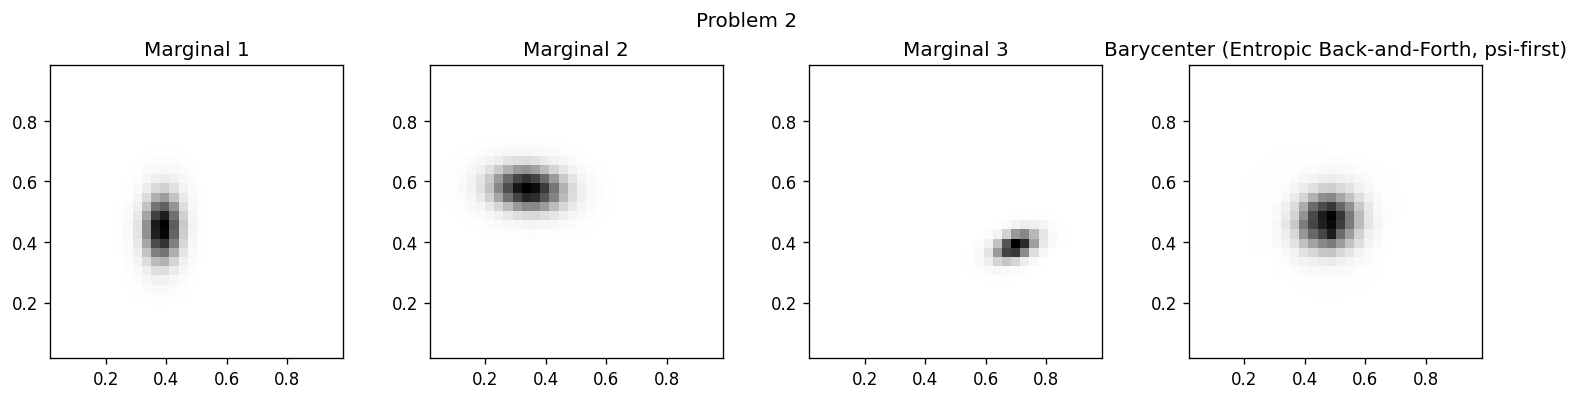

In [16]:
num_measures = len(measures)
fig, axes_arr = plt.subplots(1, num_measures + 1, figsize=(3.2 * (num_measures + 1), 3.2))
if num_measures + 1 == 1:
    axes_arr = [axes_arr]

for j, measure in enumerate(measures, start=1):
    plot_measure(axes_arr[j - 1], measure, f"Marginal {j}")

_plot_density(axes_arr[num_measures], nu_reg, grid_axes, "Barycenter (Entropic Back-and-Forth, psi-first)")

fig.suptitle("Problem 2")
plt.tight_layout()
plt.show()

In [17]:
# Back-and-forth barycenter (library solver)
print(f"{lambdas=}")
print(f"{stacked.shape=}")
print(f"{grid_axes=}")

mu_bf, diag_bf = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=50,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    # pushforward_fn=cic_pushforward_nd,
    return_monge_maps=True,
)
mu_bf = mu_bf / jnp.maximum(mu_bf.sum(), 1e-12)


lambdas=Array([0.33333333, 0.33333333, 0.33333333], dtype=float64)
stacked.shape=(3, 32, 32)
grid_axes=[Array([0.015625, 0.046875, 0.078125, 0.109375, 0.140625, 0.171875,
       0.203125, 0.234375, 0.265625, 0.296875, 0.328125, 0.359375,
       0.390625, 0.421875, 0.453125, 0.484375, 0.515625, 0.546875,
       0.578125, 0.609375, 0.640625, 0.671875, 0.703125, 0.734375,
       0.765625, 0.796875, 0.828125, 0.859375, 0.890625, 0.921875,
       0.953125, 0.984375], dtype=float64), Array([0.015625, 0.046875, 0.078125, 0.109375, 0.140625, 0.171875,
       0.203125, 0.234375, 0.265625, 0.296875, 0.328125, 0.359375,
       0.390625, 0.421875, 0.453125, 0.484375, 0.515625, 0.546875,
       0.578125, 0.609375, 0.640625, 0.671875, 0.703125, 0.734375,
       0.765625, 0.796875, 0.828125, 0.859375, 0.890625, 0.921875,
       0.953125, 0.984375], dtype=float64)]


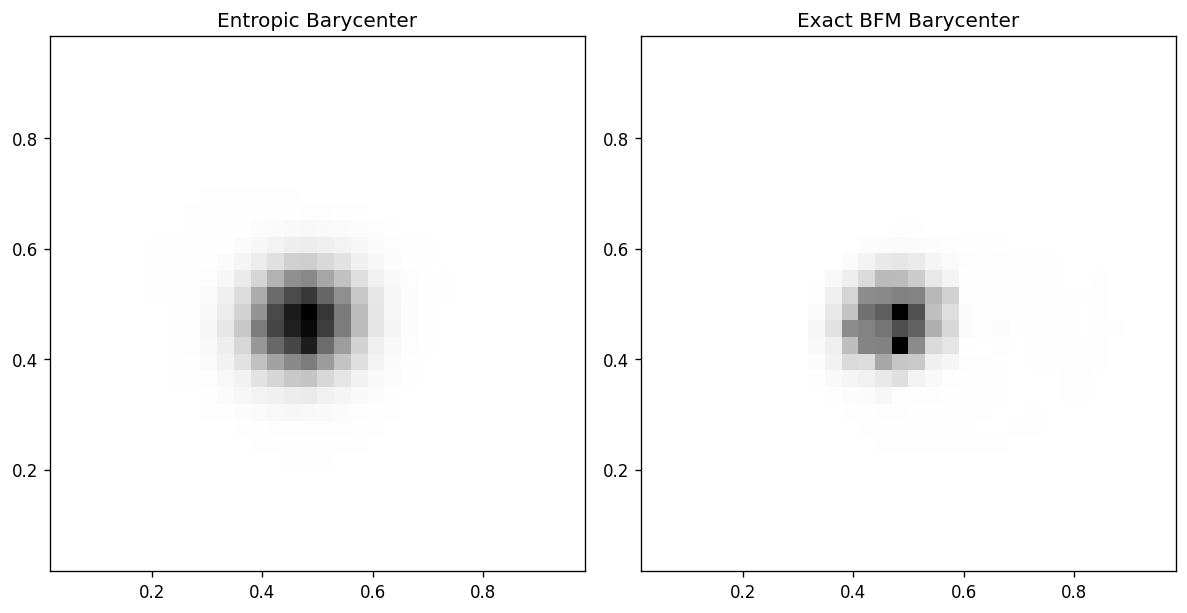

In [18]:
# 2D barycenter comparison (side-by-side)
fig_bary, axes_bary = plt.subplots(nrows=1, ncols=2, figsize=(10.0, 5.0))

_plot_density(axes_bary[0], nu_reg, grid_axes, "Entropic Barycenter")
_plot_density(axes_bary[1], mu_bf, grid_axes, "Exact BFM Barycenter")

plt.tight_layout()
plt.show()


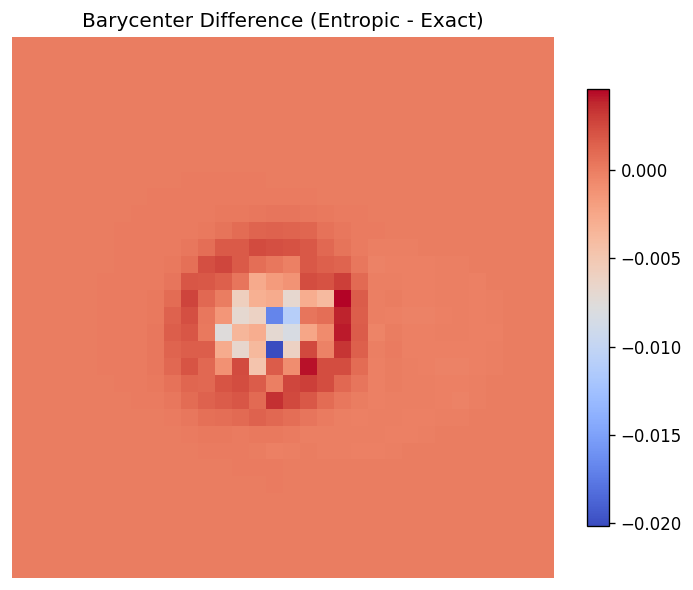

In [19]:
# 2D barycenter difference (entropic - exact)
fig_diff, ax_diff = plt.subplots(nrows=1, ncols=1, figsize=(6.0, 5.0))

diff = np.asarray(nu_reg) - np.asarray(mu_bf)
extent = (
    float(grid_axes[0][0]), float(grid_axes[0][-1]),
    float(grid_axes[1][0]), float(grid_axes[1][-1]),
)
img = ax_diff.imshow(diff.T, extent=extent, origin='lower', cmap='coolwarm')
ax_diff.set_title("Barycenter Difference (Entropic - Exact)")
ax_diff.set_axis_off()
fig_diff.colorbar(img, ax=ax_diff, shrink=0.8)

plt.tight_layout()
plt.show()


In [20]:
# Marginal residuals table (Problem 2)
res_entropic = _marginal_residuals(nu_reg, stacked, grid_axes, phi_stack=phi_reg)
res_bf = _marginal_residuals(mu_bf, stacked, grid_axes, monge_maps=diag_bf.get("monge_maps"))
_print_residual_table("Problem 2 marginal residuals (L1)", {
    "Entropic (debug)": res_entropic,
    "Back-and-forth": res_bf,
})


Problem 2 marginal residuals (L1)
method           | m0        | m1        | m2       
-----------------+-----------+-----------+----------
Entropic (debug) | 1.583e-01 | 1.730e-01 | 1.533e-01
Back-and-forth   | 3.071e-01 | 4.909e-01 | 2.247e-01


---

# TOY GENERATOR (2D) COMPARISON


In [35]:
from uot.problems.generators.toy_barycenter_generator import ToyBarycenterGenerator, FixedListSelector
from uot.solvers.sinkhorn.barycenter import barycenter_sinkhorn

# Build a 2D toy barycenter problem with 3 marginals
# selector = FixedListSelector(("Plus", "Star", "Crescent"))
selector = FixedListSelector(("Ring", "Plus", "Diamond"))
toy_gen = ToyBarycenterGenerator(
    selector=selector,
    n_points=96,
    cost_fn=cost_euclid_squared,
    num_datasets=1,
    measure_mode="grid",
    use_jax=False,
    cell_discretization="cell-centered",
)

toy_problem = toy_gen.one(num_marginals=3)
toy_measures = toy_problem.solver_inputs(include_cost=False).marginals
toy_axes = toy_measures[0].axes
toy_stacked = _stack_grid_measures(toy_measures)
toy_lambdas = jnp.asarray(toy_problem.lambdas())

In [36]:
# Back-and-forth barycenter (library solver)
start_t = time.perf_counter()
mu_bf_toy, diag_bf_toy = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=toy_lambdas,
    measures_weights=toy_stacked,
    coordinates=toy_axes,
    outer_maxiter=80,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=5e-4,
    # pushforward_fn=cic_pushforward_nd,
    return_monge_maps=True,
)
_wait_jax_finish(mu_bf_toy)
mu_bf_toy = mu_bf_toy / jnp.maximum(mu_bf_toy.sum(), 1e-12)
runtime_toy_bf = time.perf_counter() - start_t

In [58]:
# Sinkhorn barycenter on shared support
start_t = time.perf_counter()
support, meas_array, cost_matrix, lambdas = toy_problem.shared_support_inputs(
    include_zeros=True,
)
sinkhorn_reg = 3e-4
b_sinkhorn, info_sinkhorn = barycenter_sinkhorn(
    measures=jnp.asarray(meas_array),
    cost=jnp.asarray(cost_matrix),
    lambdas=jnp.asarray(lambdas),
    reg=sinkhorn_reg,
    tol=1e-4,
    maxiter=800,
    return_diagnostics=True,
)
_wait_jax_finish(b_sinkhorn)

# reshape sinkhorn barycenter to grid for plotting
shape = tuple(len(ax) for ax in toy_axes)
b_sinkhorn_grid = np.asarray(b_sinkhorn).reshape(shape)
runtime_toy_sinkhorn = time.perf_counter() - start_t

In [60]:
# Entropic barycenter (debug solver)
start_t = time.perf_counter()
ent_barycenter_reg = 1e-4
nu_toy, psi_toy, phi_toy, diag_toy = entropic_barycenter_sobolev_gradient_ascent_dual_scan(
    mu_list=[toy_stacked[i] for i in range(toy_stacked.shape[0])],
    lambda_list=toy_lambdas,
    coordinates=toy_axes,
    gamma=ent_barycenter_reg,
    num_outer_iters=600,
    outer_tol=5e-4,
    pushforward_fn=cic_pushforward_nd,
)
_wait_jax_finish(nu_toy)
nu_toy = nu_toy / jnp.maximum(nu_toy.sum(), 1e-12)
runtime_toy_entropic = time.perf_counter() - start_t

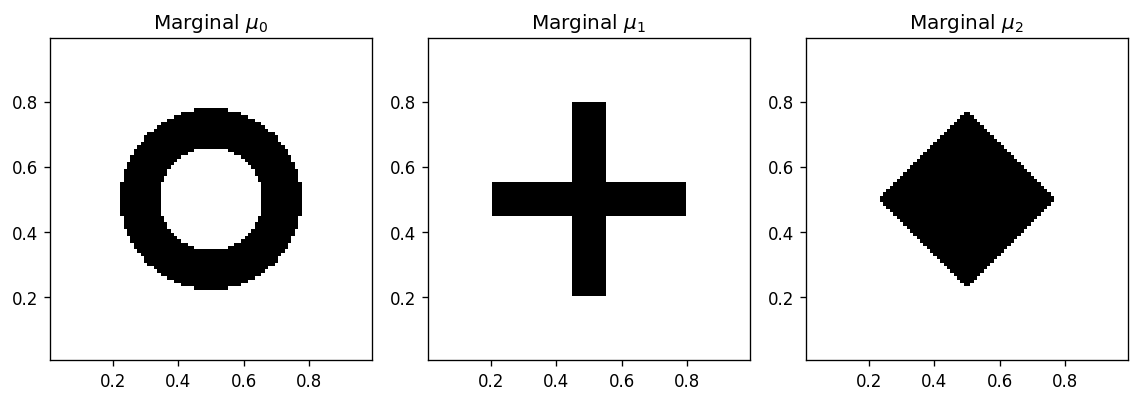

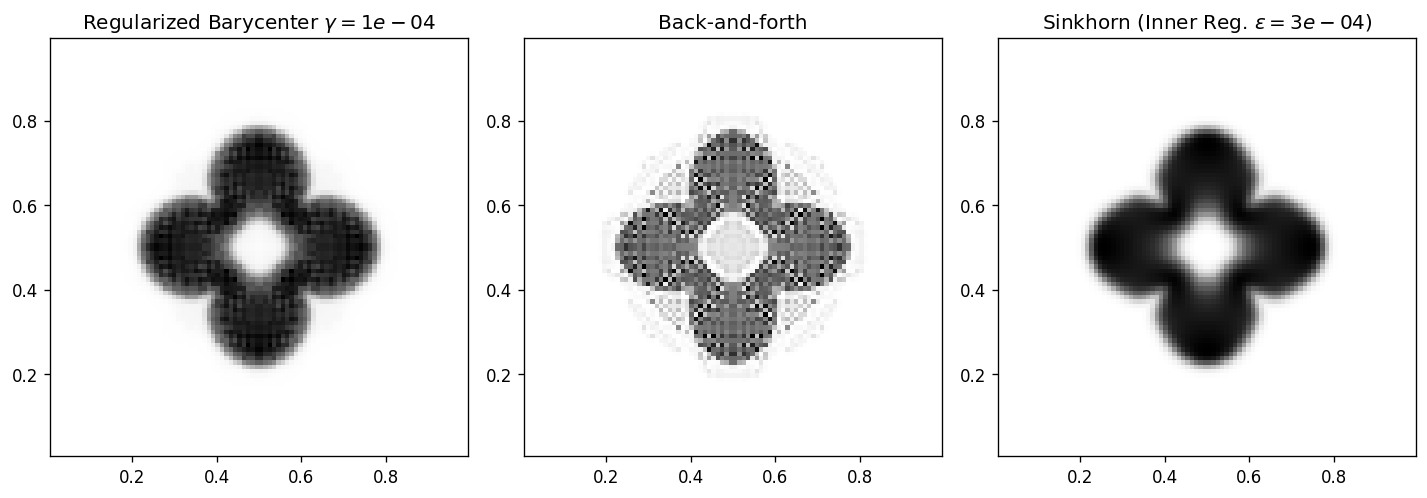

In [67]:
# Plot marginals
fig_marg, axes_marg = plt.subplots(1, len(toy_measures), figsize=(3.2 * len(toy_measures), 3.2))
if len(toy_measures) == 1:
    axes_marg = [axes_marg]
for i, m in enumerate(toy_measures):
    plot_measure(axes_marg[i], m, f"Marginal $\\mu_{i}$")
plt.tight_layout()
plt.show()

# Plot barycenters side-by-side (2D)
fig_bary, axes_bary = plt.subplots(1, 3, figsize=(12.0, 4.0))
_plot_density(axes_bary[0], nu_toy, toy_axes, f"Regularized Barycenter $\\gamma = {ent_barycenter_reg:.0e}$")
_plot_density(axes_bary[1], mu_bf_toy, toy_axes, "Back-and-forth")
_plot_density(axes_bary[2], b_sinkhorn_grid, toy_axes, f"Sinkhorn (Inner Reg. $\\varepsilon={sinkhorn_reg:.0e}$)")
plt.tight_layout()
plt.show()


In [56]:
# Marginal residuals table (Toy generator)
res_toy_entropic = _marginal_residuals(nu_toy, toy_stacked, toy_axes, phi_stack=phi_toy)
res_toy_bf = _marginal_residuals(mu_bf_toy, toy_stacked, toy_axes, monge_maps=diag_bf_toy.get("monge_maps"))
res_toy_sinkhorn = _sinkhorn_barycentric_residuals(
    b_sinkhorn, toy_stacked, support, cost_matrix, reg=5e-4, diagnostics=info_sinkhorn
)
_print_residual_table("Toy marginal residuals (L1)", {
    "Entropic (debug)": res_toy_entropic,
    "Back-and-forth": res_toy_bf,
    "Sinkhorn": res_toy_sinkhorn,
})


Toy marginal residuals (L1)
method           | m0        | m1        | m2       
-----------------+-----------+-----------+----------
Entropic (debug) | 2.557e-01 | 1.626e-01 | 1.132e-01
Back-and-forth   | 2.899e-01 | 2.838e-01 | 1.940e-01
Sinkhorn         | 1.280e+00 | 1.331e+00 | 1.272e+00


In [57]:
# Runtime stats (Toy generator)
_print_runtime_table("Toy runtimes (seconds)", {
    "Entropic (debug)": float(runtime_toy_entropic),
    "Back-and-forth": float(runtime_toy_bf),
    "Sinkhorn": float(runtime_toy_sinkhorn),
})


Toy runtimes (seconds)
method           | seconds
-----------------+--------
Entropic (debug) | 6.657  
Back-and-forth   | 46.692 
Sinkhorn         | 11.855 


# Regularized-Barycenters with different $\gamma$ regularization strength

We are going to use the same toy example of shapes.

The list of available shapes is:
- `Ring`
- `GMM`
- `Crescent`
- `Plus`
- `Diamond`
- `Square`
- `Two Squares`
- `Checker`
- `Star`

In [28]:
# selector = FixedListSelector(("Ring", "Checker", "Two Squares"))
selector = FixedListSelector(("Ring", "Plus", "Diamond"))
toy_gen = ToyBarycenterGenerator(
    selector=selector,
    n_points=192,
    # n_points=96,
    cost_fn=cost_euclid_squared,
    num_datasets=1,
    measure_mode="grid",
    use_jax=False,
    cell_discretization="cell-centered",
)

toy_problem = toy_gen.one(num_marginals=3)
toy_measures = toy_problem.solver_inputs(include_cost=False).marginals
toy_axes = toy_measures[0].axes
toy_stacked = _stack_grid_measures(toy_measures)

# toy_lambdas = jnp.asarray(toy_problem.lambdas())
toy_lambdas = jnp.asarray([1/3, 1/3, 1/3])

In [29]:
gamma_values = jnp.logspace(-6, -3, num=6)[2:]
max_iterations = 800
tolerance = 5e-4

run_results = []

def run_reg_grad_asc_for_gamma(gamma):
    start_t = time.perf_counter()
    nu_toy, psi_toy, phi_toy, diag_toy = entropic_barycenter_sobolev_gradient_ascent_dual_scan(
        mu_list=[toy_stacked[i] for i in range(toy_stacked.shape[0])],
        lambda_list=toy_lambdas,
        coordinates=toy_axes,
        gamma=gamma,
        num_outer_iters=max_iterations,
        outer_tol=tolerance,
        pushforward_fn=cic_pushforward_nd,
    )
    # nu_toy = nu_toy / jnp.maximum(nu_toy.sum(), 1e-12)
    _wait_jax_finish(nu_toy)
    runtime_toy_entropic = time.perf_counter() - start_t
    return {
        "gamma": gamma,
        "nu": nu_toy,                                           # (*grid)
        "psi": psi_toy,                                         # (n, *grid)
        "phi": phi_toy,                                         # (n, *grid)
        "iterations": diag_toy['iterations'],                   # T
        "source_mismatch": diag_toy['source_mismatch'],         # (T, n)
        "max_source_mismatch": diag_toy['max_source_mismatch'], # (T,)
        "eta_history": diag_toy['eta_history'],                 # (T,)
        "dual_history": diag_toy['dual_history'],               # (T,)
        "grad_sq_history": diag_toy['grad_sq_history'],         # (T,)

        "runtime": runtime_toy_entropic,
    }

for i, gamma in enumerate(gamma_values):
    i_run_res = run_reg_grad_asc_for_gamma(gamma=gamma)
    run_results.append(i_run_res)
    print(f"[{i}] gamma = {gamma:.6f} finished in {i_run_res['runtime']:.6f} seconds with {i_run_res['iterations']} iterations done")


[0] gamma = 0.000016 finished in 47.102699 seconds with 800 iterations done
[1] gamma = 0.000063 finished in 53.858308 seconds with 800 iterations done
[2] gamma = 0.000251 finished in 59.700585 seconds with 800 iterations done
[3] gamma = 0.001000 finished in 66.459789 seconds with 800 iterations done


<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
/var/folders/zt/h5ncncv1043cdpswcj8nysgm0000gn/T/ipykernel_916/2725557761.py:7: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  _plot_density(axes_baries[i], res['nu'], toy_axes, f"$\gamma={res['gamma']:.1e}$")


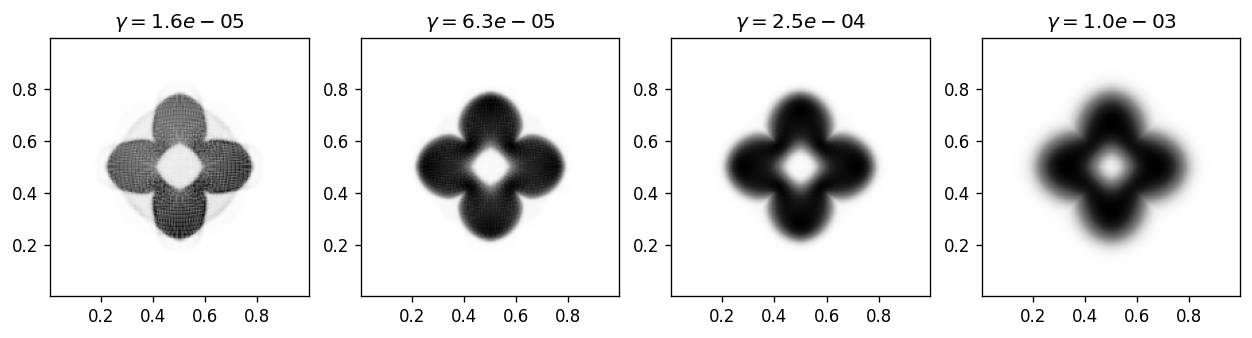

In [30]:
# Plot marginals
fig_baries, axes_baries = plt.subplots(1, len(gamma_values), figsize=(3.2 * len(gamma_values), 3.2))
if len(gamma_values) == 1:
    axes_baries = [axes_baries]

for i, res in enumerate(run_results):
    _plot_density(axes_baries[i], res['nu'], toy_axes, f"$\gamma={res['gamma']:.1e}$")
    # _plot_density(axes_baries[i], res['nu'], toy_axes, f"Regularized-Barycenter with gamma={res['gamma']}")

# plt.tight_layout()
plt.show()

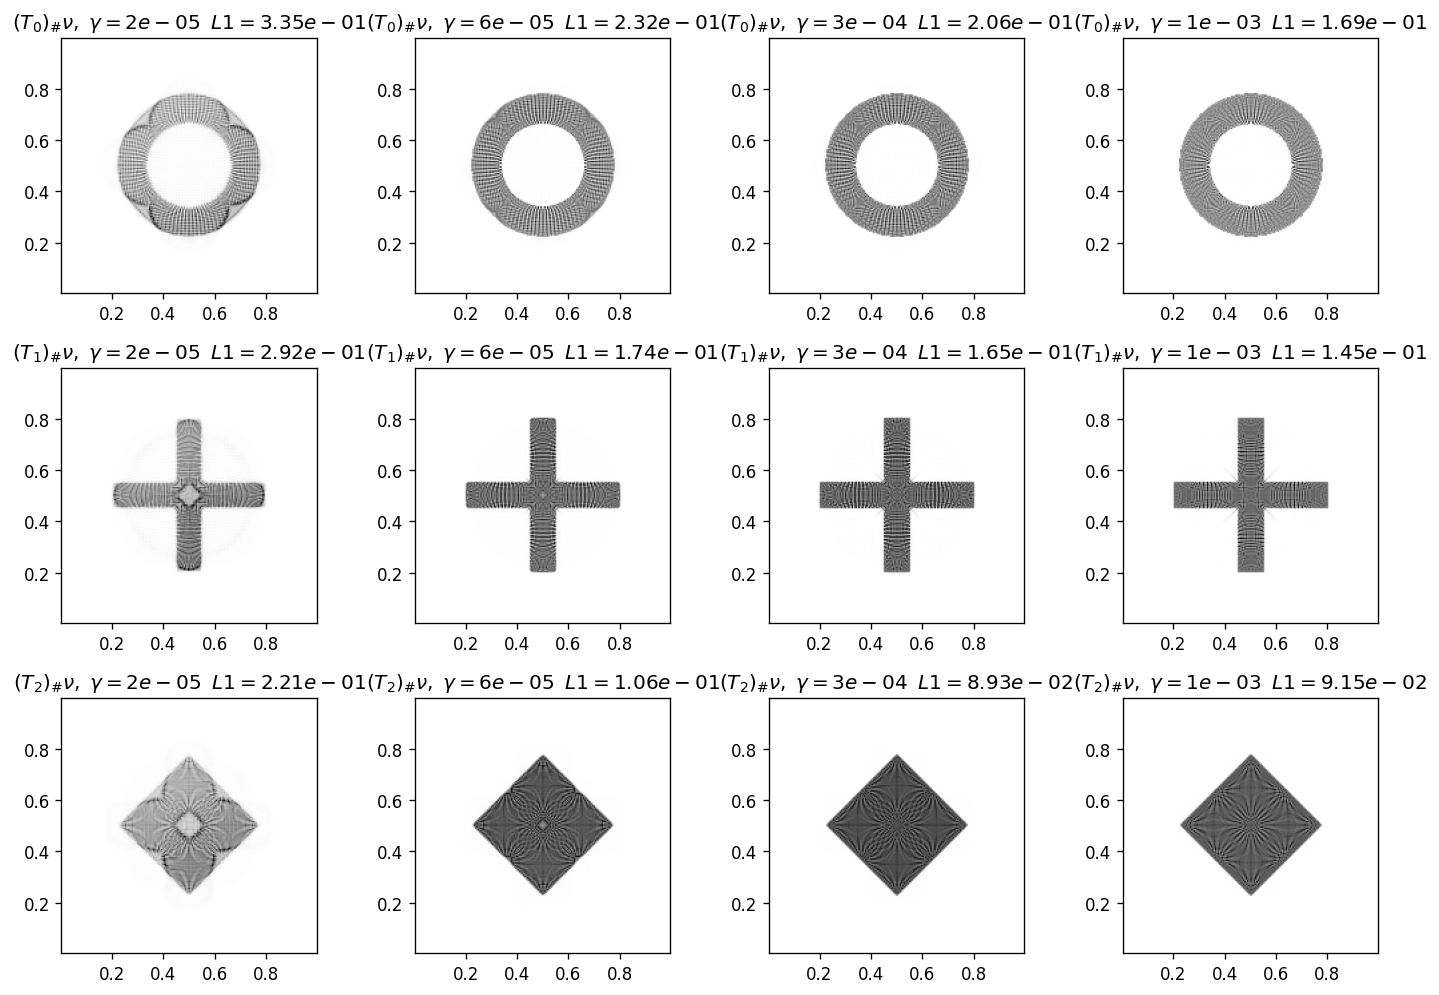

In [31]:
# Pushforward marginals across gammas (rows: marginal index; cols: gamma)
num_marginals = toy_stacked.shape[0]
num_gammas = len(run_results)

fig_push, axes_push = plt.subplots(num_marginals, num_gammas,
                                  figsize=(3.0 * num_gammas, 2.8 * num_marginals))
if num_marginals == 1 and num_gammas == 1:
    axes_push = np.array([[axes_push]])
elif num_marginals == 1:
    axes_push = np.array([axes_push])
elif num_gammas == 1:
    axes_push = np.array(axes_push).reshape(num_marginals, 1)

for j, res in enumerate(run_results):
    gamma = res["gamma"]
    monge_maps = jax.vmap(monge_map_cic_from_psi_nd, in_axes=0, out_axes=0)(res["phi"])
    pushed_marginals = jax.vmap(lambda M: cic_pushforward_nd(res["nu"], M), in_axes=0, out_axes=0)(monge_maps)
    for i in range(num_marginals):
        l1_res = jnp.sum(jnp.abs(pushed_marginals[i] - toy_stacked[i]))
        _plot_density(axes_push[i, j], pushed_marginals[i], toy_axes,
                      f"$(T_{i})_\\# \\nu, \\; \\gamma={gamma:.0e} \\;\\; L1={float(l1_res):.2e}$")

plt.tight_layout()
plt.show()


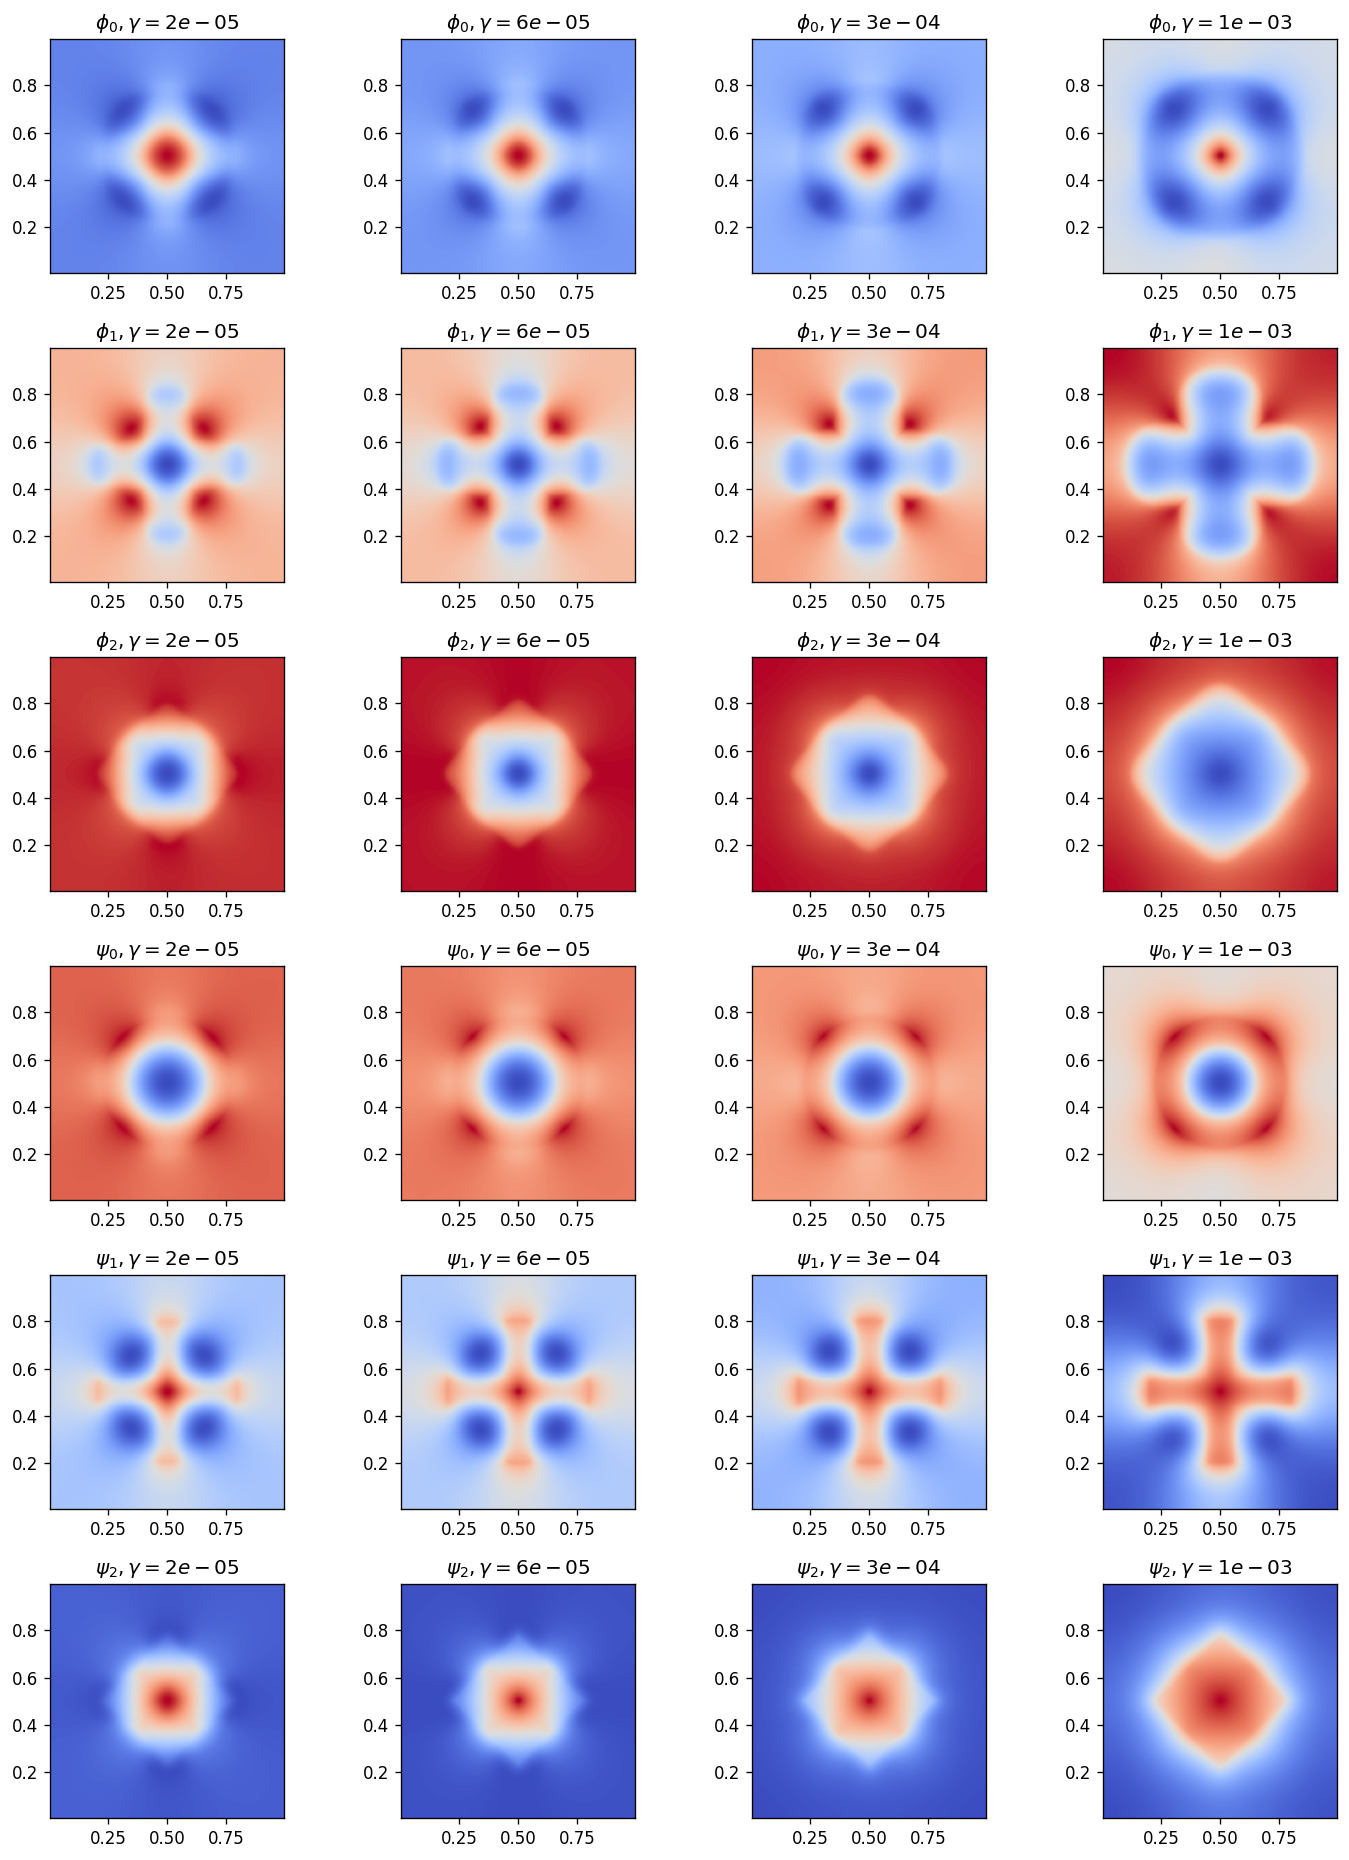

In [32]:
# Potentials across gammas (rows: phi_i then psi_i; cols: gamma)
num_marginals = run_results[0]["phi"].shape[0]
num_gammas = len(run_results)

fig, axes = plt.subplots(2 * num_marginals, num_gammas,
                         figsize=(3.0 * num_gammas, 2.6 * 2 * num_marginals))
if num_gammas == 1:
    axes = np.array(axes).reshape(2 * num_marginals, 1)

for j, res in enumerate(run_results):
    gamma = res["gamma"]
    phi = res["phi"]
    psi = res["psi"]
    for i in range(num_marginals):
        ax_phi = axes[i, j]
        _plot_density(ax_phi, phi[i], toy_axes, f"$\\phi_{i}, \\gamma={gamma:.0e}$", cmap="coolwarm")
        ax_psi = axes[num_marginals + i, j]
        _plot_density(ax_psi, psi[i], toy_axes, f"$\\psi_{i}, \\gamma={gamma:.0e}$", cmap="coolwarm")

plt.tight_layout()
plt.show()


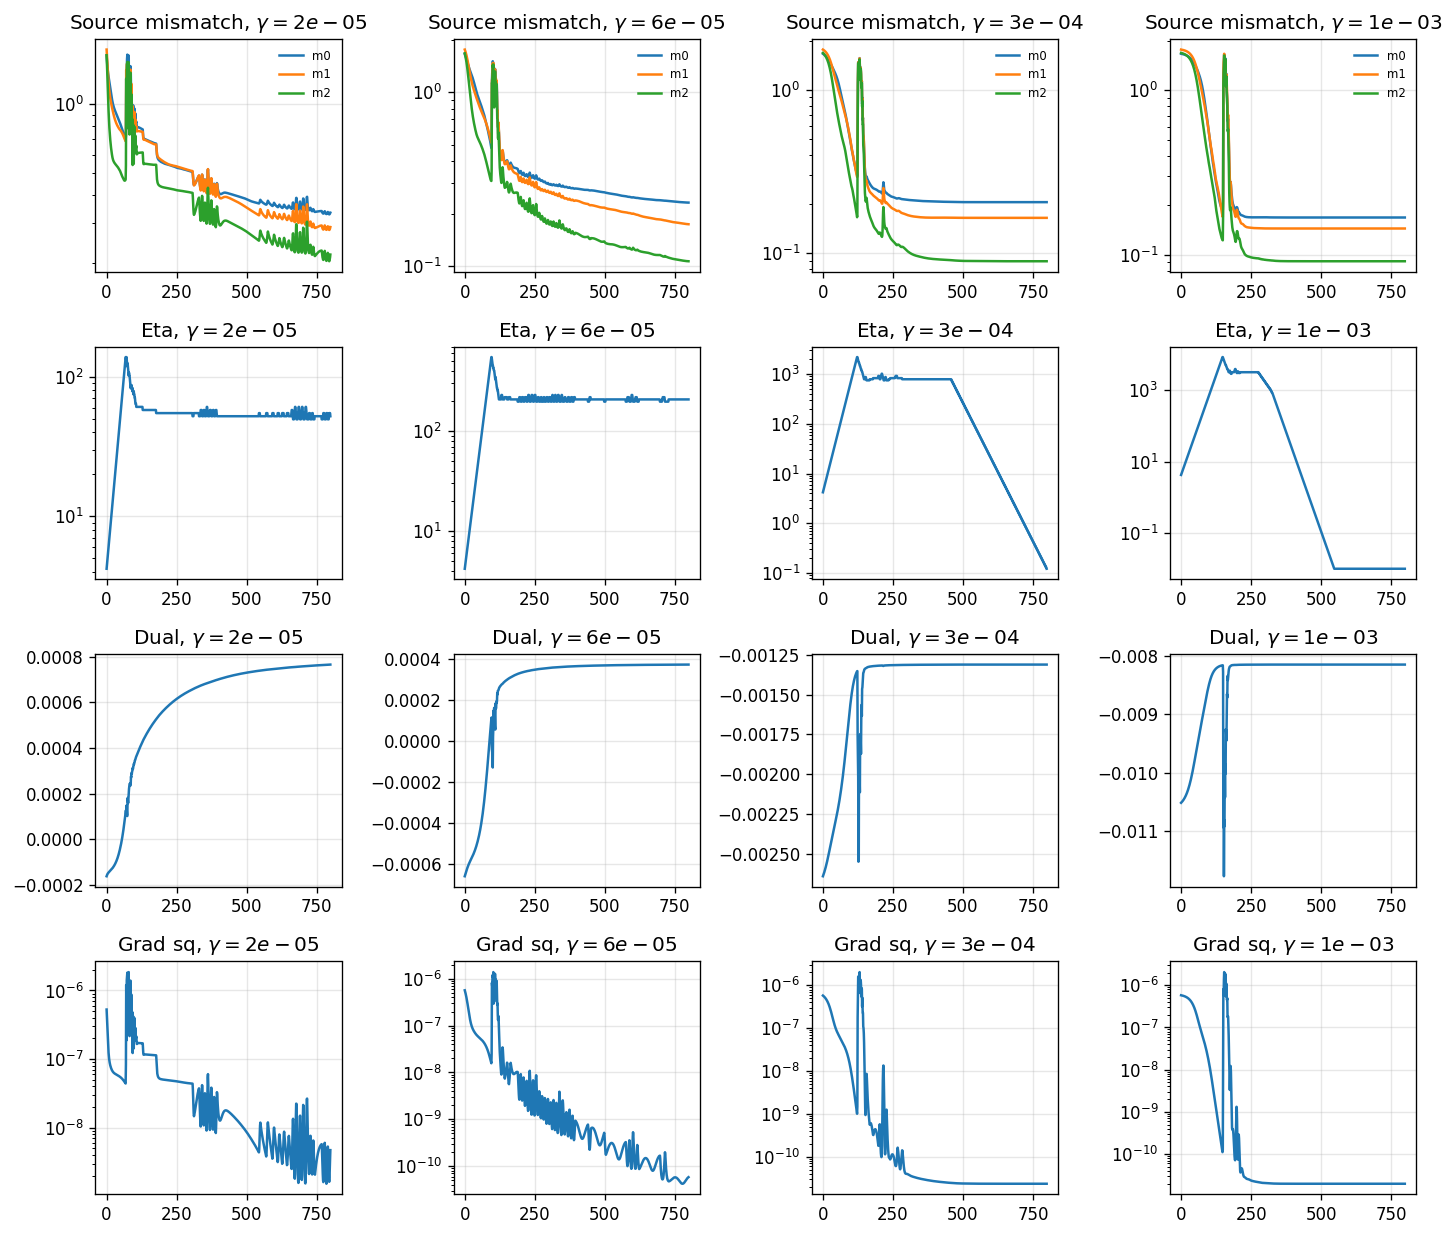

In [33]:
# Histories across gammas (rows: metrics; cols: gamma)
metrics = [
    ("source_mismatch", "Source mismatch"),
    ("eta_history", "Eta"),
    ("dual_history", "Dual"),
    ("grad_sq_history", "Grad sq"),
]
num_gammas = len(run_results)
fig, axes = plt.subplots(len(metrics), num_gammas,
                         figsize=(3.0 * num_gammas, 2.6 * len(metrics)))
if num_gammas == 1:
    axes = np.array(axes).reshape(len(metrics), 1)

for j, res in enumerate(run_results):
    gamma = res["gamma"]
    for i, (key, title) in enumerate(metrics):
        ax = axes[i, j]
        val = res[key]
        if key == "source_mismatch":
            # val shape: (T, n)
            for k in range(val.shape[1]):
                ax.plot(val[:, k], label=f"m{k}")
        else:
            ax.plot(val)
        ax.set_title(f"{title}, $\\gamma={gamma:.0e}$")
        if key in ("source_mismatch", "eta_history", "grad_sq_history"):
            ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        if key == "source_mismatch":
            ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
# plt.show()
